# Evaluation of Custom Verifiers for Personalized Wake Word Detection

To evaluate the impact of the amount of training data on the custom verifier performance, three different verifier models were trained using varying numbers of positive training samples. Each model was then evaluated using test samples from different speakers to analyze its generalization capability. Additionally, the verifiers were tested on the Santa Barbara Corpus to measure their performance on a larger and more diverse speech dataset. Furthermore, a comparison between male and female test data was conducted to investigate whether the verifier performance differs depending on the speaker's gender. In future work, the evaluation will be extended by using a significantly larger amount of synthetic speech data to further investigate the robustness and scalability of the custom verifier.



In [ ]:
!pip install openwakeword
!pip install onnxruntime

In [ ]:
import matplotlib.pyplot as plt
from openwakeword.model import Model
import numpy as np
from google.colab import drive
import glob
import openwakeword
import openwakeword.metrics
import soundfile as sf
import librosa
import os

In [ ]:
# Connect google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preparation of the data

In [ ]:
recordings_dir = "/content/drive/MyDrive/speech_interaction/recordings"
output_dir = "/content/drive/MyDrive/speech_interaction/recordings_converted"

# Find all recordings
all_wav_files = glob.glob(f"{recordings_dir}/**/*.wav", recursive=True)
print(f"Found: {len(all_wav_files)} files\n")

converted = 0
already_ok = 0

for filepath in all_wav_files:
    audio, sr = sf.read(filepath)

    # Rebuild folder structure
    relative_path = os.path.relpath(filepath, recordings_dir)
    output_path = os.path.join(output_dir, relative_path)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    needs_conversion = sr != 16000 or audio.ndim > 1

    if needs_conversion:
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        if sr != 16000:
            audio = librosa.resample(audio.astype(np.float32), orig_sr=sr, target_sr=16000)
        audio_int16 = (audio * 32767).astype(np.int16)
        sf.write(output_path, audio_int16, 16000)
        print(f"✅ Converted: {relative_path}")
        converted += 1
    else:
        # Simple copy
        import shutil
        shutil.copy2(filepath, output_path)
        print(f"📋 Kopiert: {relative_path}")
        already_ok += 1

print(f"\nFinished! {converted} converted, {already_ok} copied.")
print(f"Saved in: {output_dir}")

Found: 51 files

📋 Kopiert: test/false/Lotte 2.wav
📋 Kopiert: test/false/Lotte 4.wav
📋 Kopiert: test/false/Lotte 1.wav
📋 Kopiert: test/false/Lotte 3.wav
📋 Kopiert: test/false/Marie 3.wav
📋 Kopiert: test/false/Marie 4.wav
📋 Kopiert: test/false/Marie 5.wav
📋 Kopiert: test/false/Lotte 5.wav
📋 Kopiert: test/false/Marie 2.wav
📋 Kopiert: test/false/Marie 1.wav
✅ Converted: test/false/Julia test 4.wav
✅ Converted: test/false/Julia test 5.wav
✅ Converted: test/false/Julia test 1.wav
✅ Converted: test/false/Julia test 2.wav
✅ Converted: test/false/Julia test 3.wav
✅ Converted: test/false/m_alex_test_5.wav
✅ Converted: test/false/m_alex_test_4.wav
✅ Converted: test/false/m_alex_test_3.wav
✅ Converted: test/false/m_alex_test_2.wav
✅ Converted: test/false/m_alex_test_1.wav
✅ Converted: test/false/m_felix_test_5.wav
✅ Converted: test/false/m_felix_test_4.wav
✅ Converted: test/false/m_felix_test_3.wav
✅ Converted: test/false/m_felix_test_2.wav
✅ Converted: test/false/m_felix_test_1.wav
📋 Kopiert: te

In [ ]:
# Connect to trainings data and find amount of audio data
base_path = "/content/drive/MyDrive/speech_interaction/recordings_converted/"

# Train clips
true_train_clips = glob.glob(f"{base_path}training/true/*.wav")
false_train_clips = glob.glob(f"{base_path}training/false/*.wav")

print(f"True train Clips found:, {len(true_train_clips)}")
print(true_train_clips)
print(f"False train Clips found:, {len(false_train_clips)}")
print(false_train_clips)

# Test clips

true_test_clips = glob.glob(f"{base_path}test/true/*.wav")
false_test_clips = glob.glob(f"{base_path}test/false/*.wav")

print(f"True test Clips found:, {len(true_test_clips)}")
print(true_test_clips)
print(f"False test Clips found:, {len(false_test_clips)}")
print(false_test_clips)

True train Clips found:, 10
['/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 5.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 3.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 9.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 2.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 1.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 8.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 6.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 4.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 7.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 10.wav']
False train Clips found:, 11
['/content/

## Evaluation of the Baseline OpenWakeWord Model

The goal is to establish a baseline by analyzing the performance of a standard OpenWakeWord model provided by the library. This serves as a reference point for comparison with the enhanced system that combines the wake word model with a custom-trained verifier.

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the Santa Barbara corpus


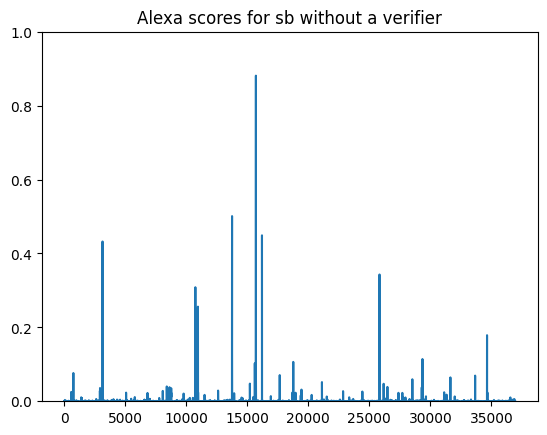

False-accept rate per hour: 4.87


In [ ]:
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

alexa_model = Model(wakeword_model_paths=[wakeword_alexa],)


# Saint Barbara
print("Running false-positive analysis on the Santa Barbara corpus")
sb_scores = alexa_model.predict_clip(sb_corpus_clip)


plt.figure()
plt.title("Alexa scores for sb without a verifier")
plt.plot([i["alexa"] for i in sb_scores])
_ = plt.ylim(0,1)
plt.show()
plt.close()


# Calculate the false-accept rate per hour from this new result

false_accepts = openwakeword.metrics.get_false_positives(
    [i["alexa"] for i in sb_scores], threshold=0.6
)

duration_sec = sf.info(sb_corpus_clip).duration
duration_hr = duration_sec / 3600

print(f"False-accept rate per hour: {false_accepts / duration_hr:.2f}")

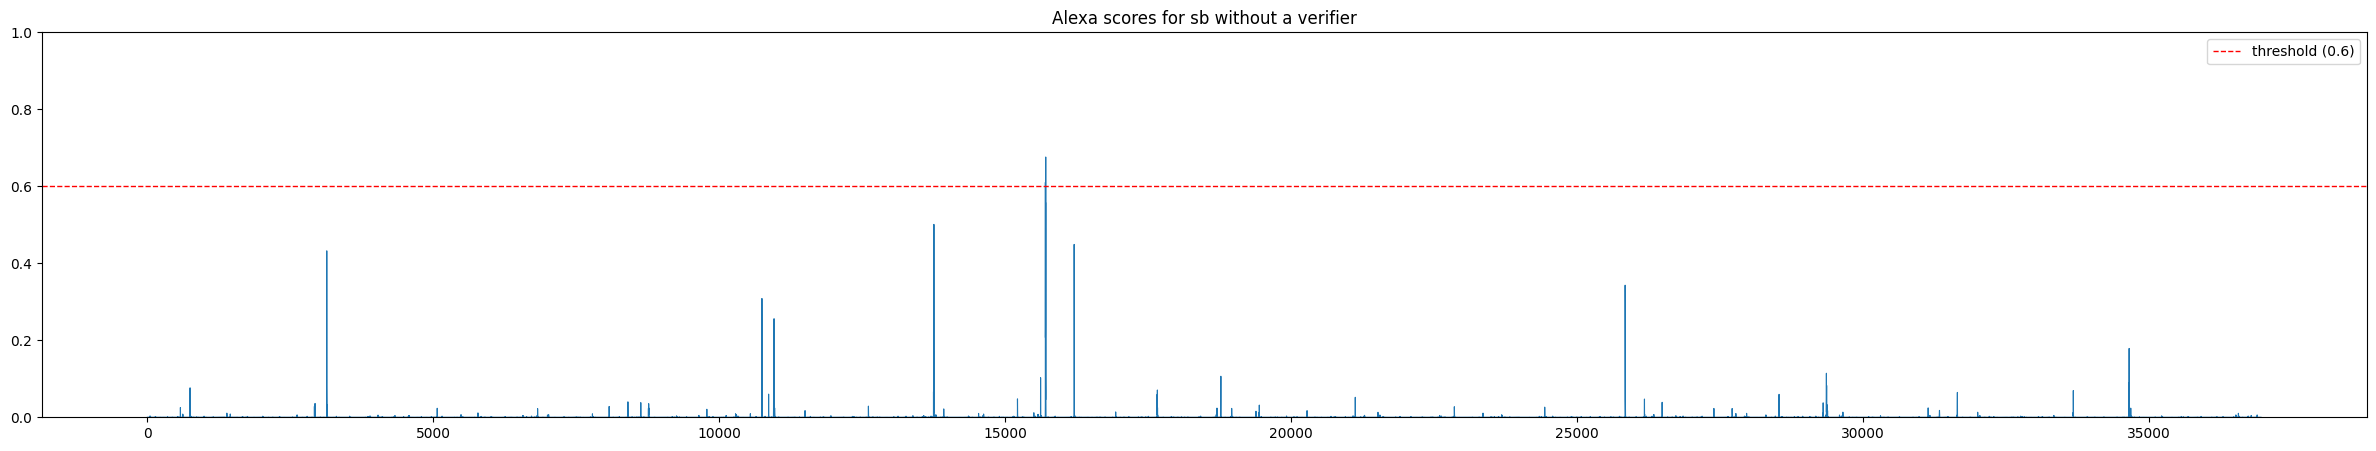

In [ ]:
plt.figure(figsize=(30, 5))  # much wider, modest height
plt.title("Alexa scores for sb without a verifier")
plt.plot([i["alexa"] for i in sb_scores], linewidth=0.8)
plt.axhline(0.6, color="red", linestyle="--", linewidth=1, label="threshold (0.6)")
plt.ylim(0, 1)
plt.legend()
plt.show()
plt.close()

TO DO: Auwertung der Grafik

In [ ]:
print(sf.info(sb_corpus_clip).duration)

2954.435625


In [ ]:
print(false_accepts, type(false_accepts))

0 <class 'numpy.int64'>


Evaluating the alexa model


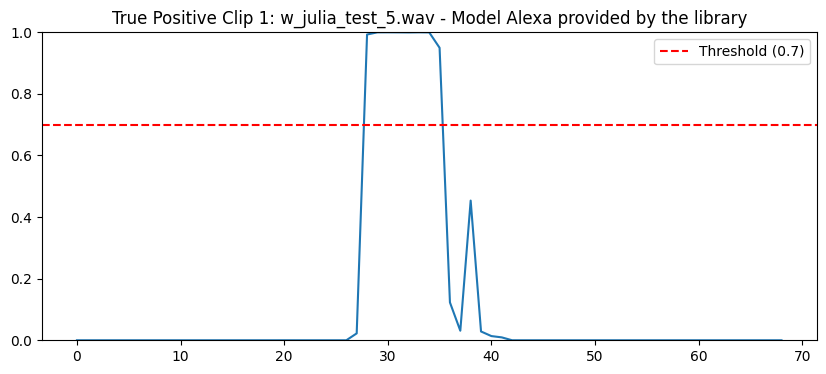

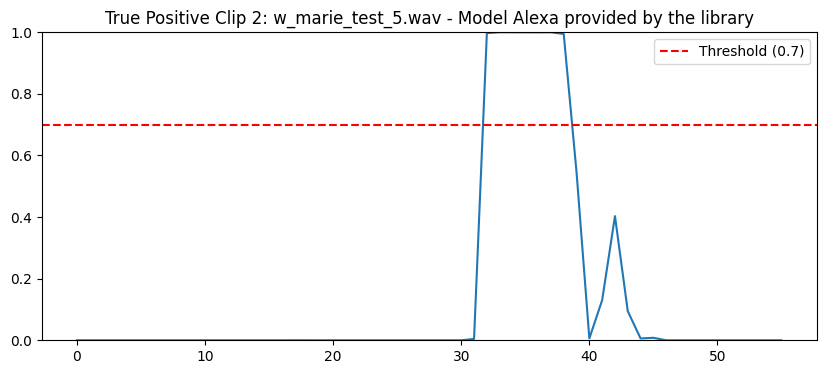

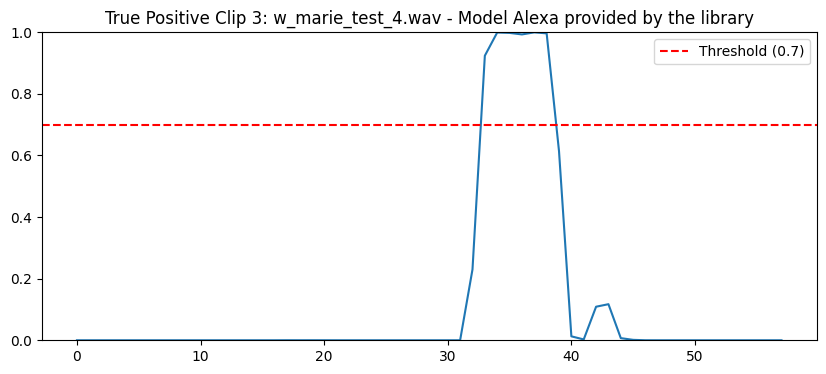

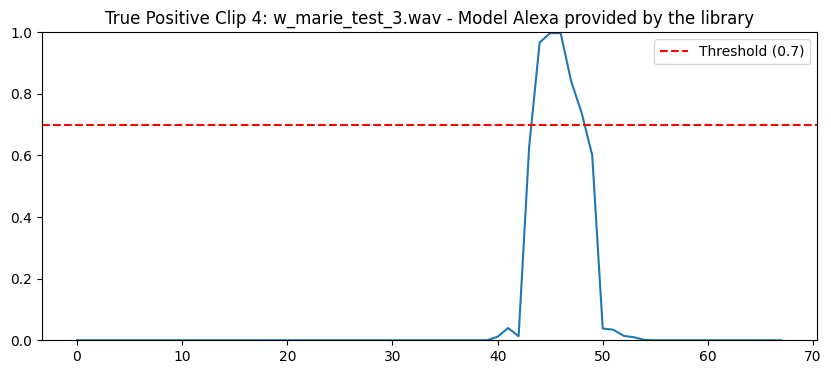

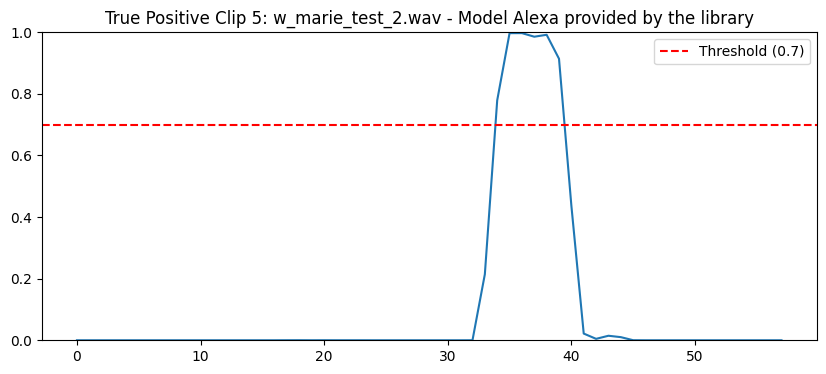

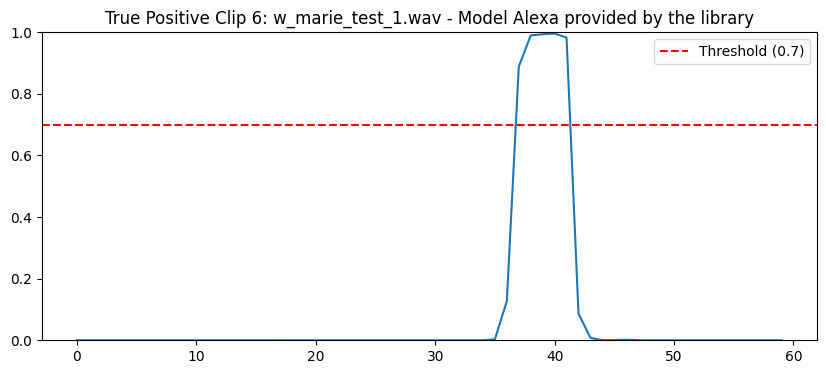

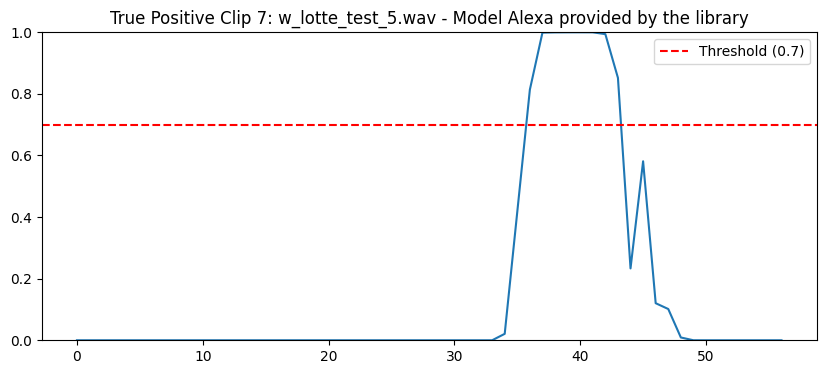

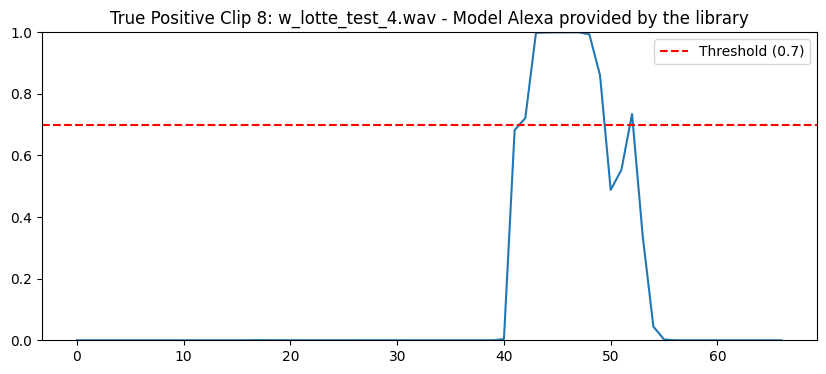

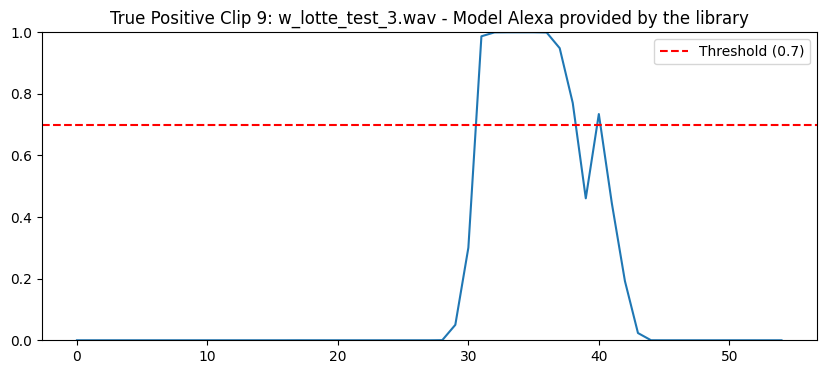

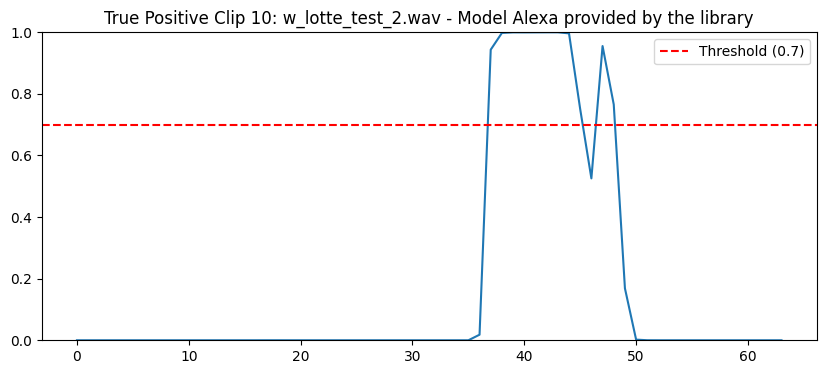

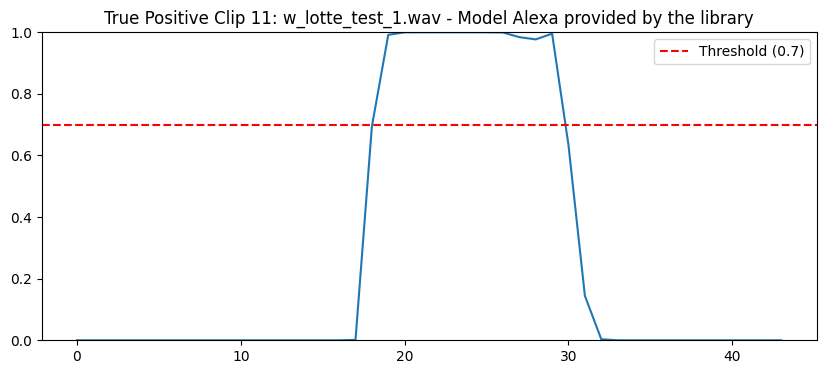

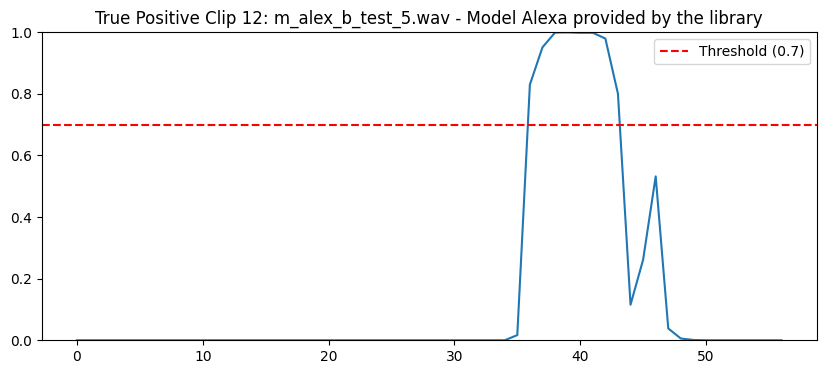

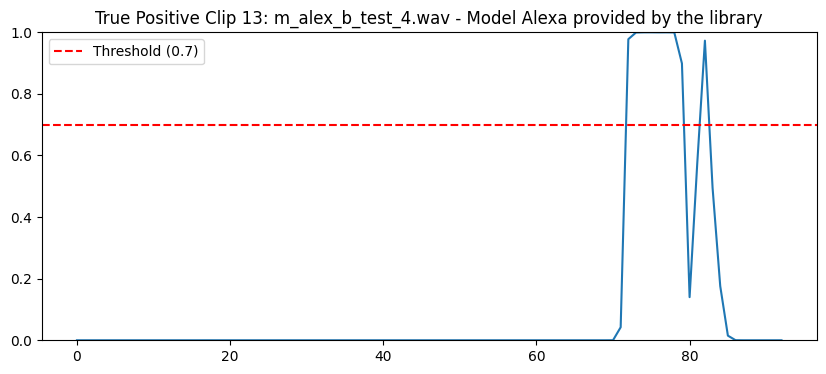

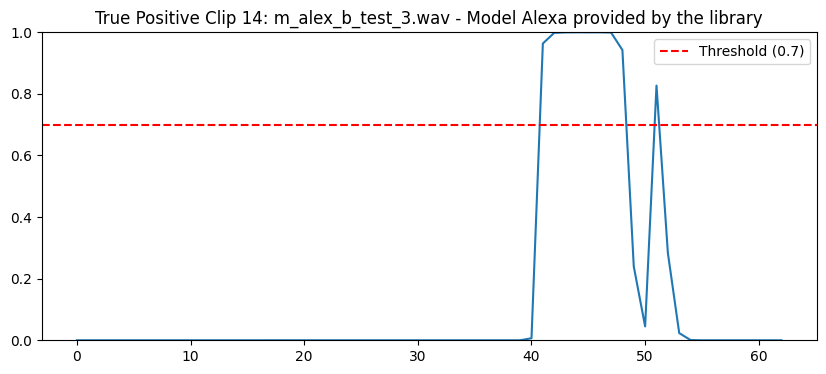

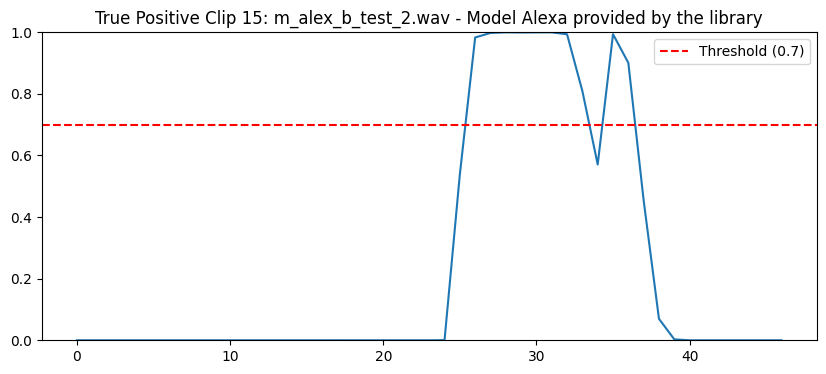

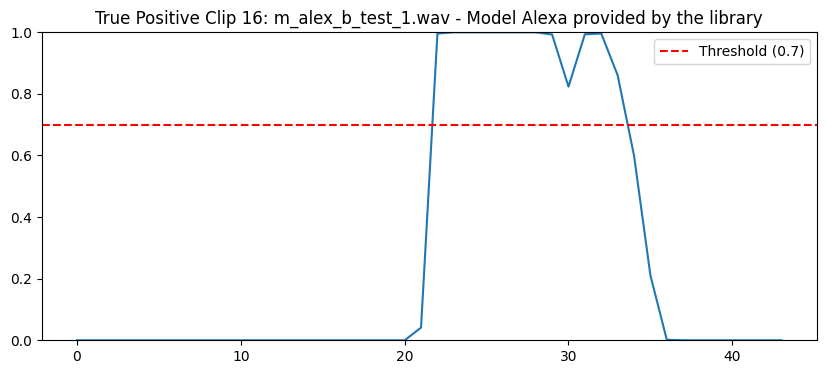

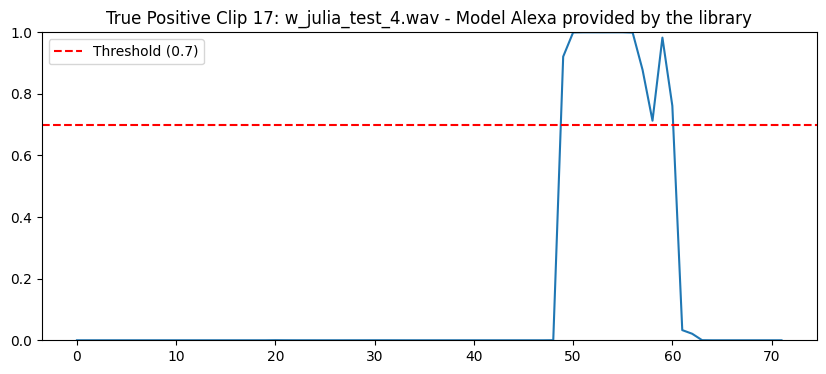

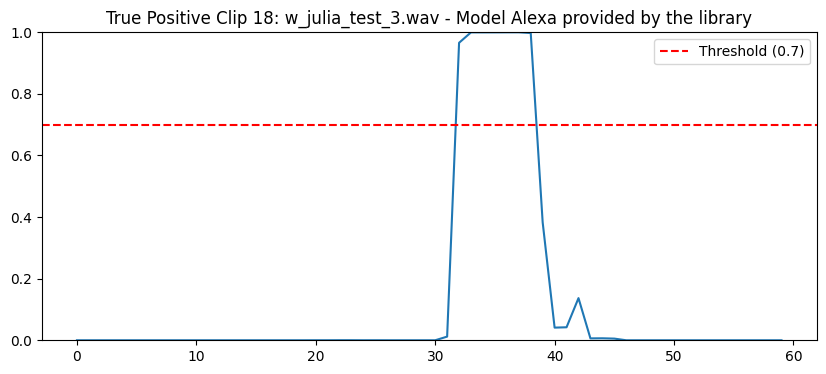

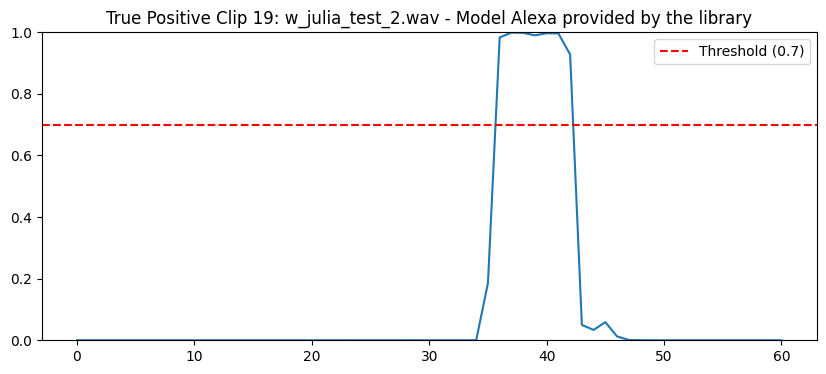

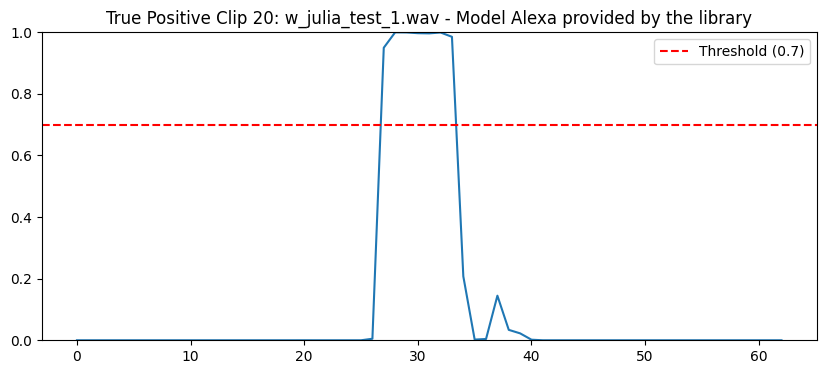

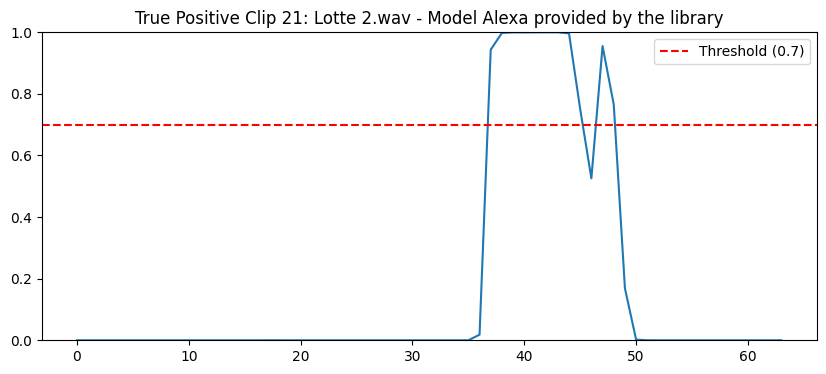

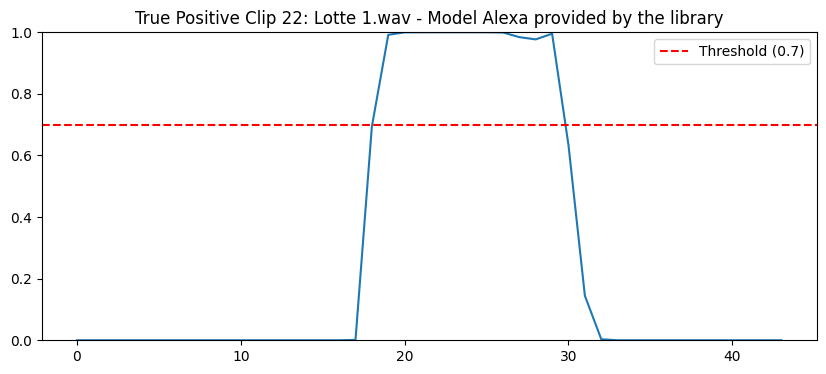

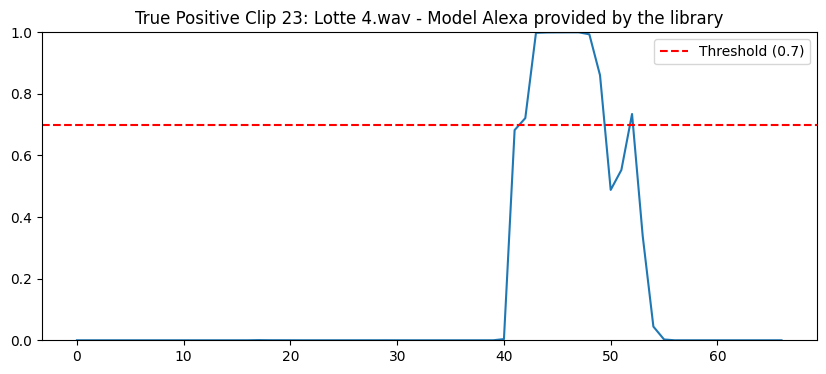

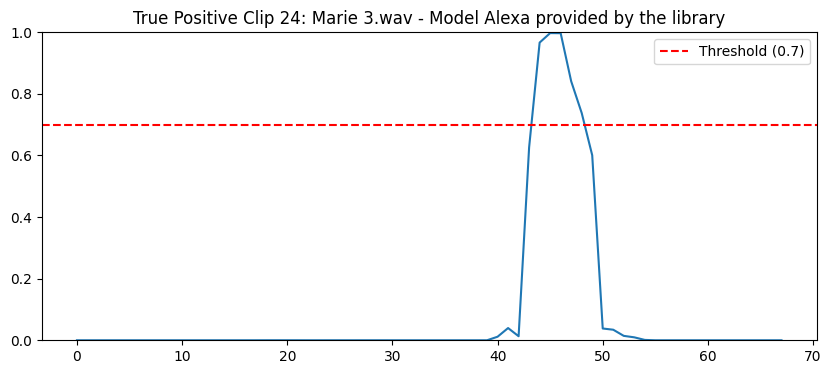

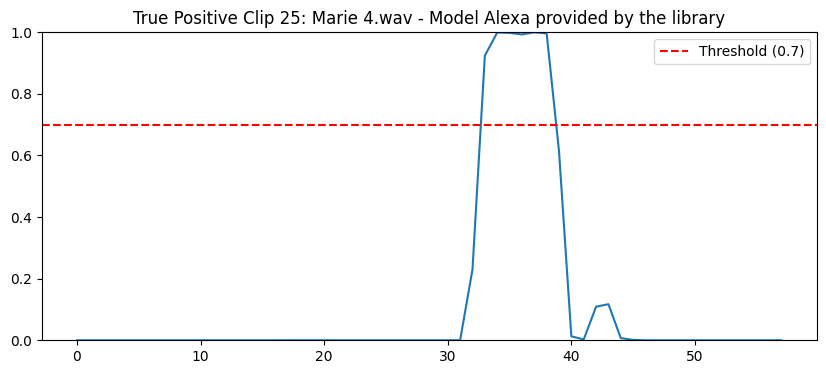

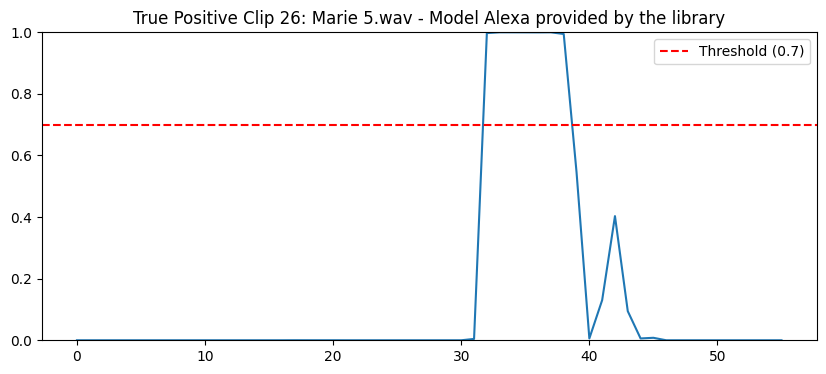

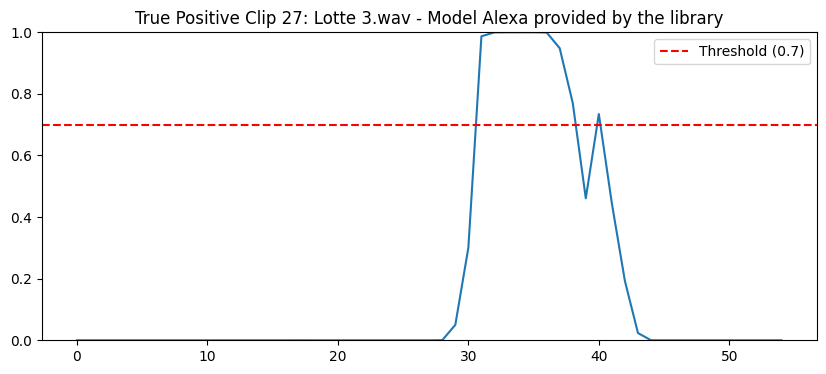

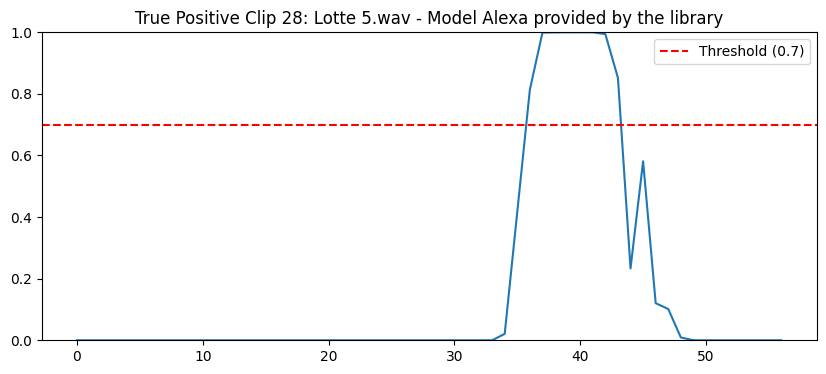

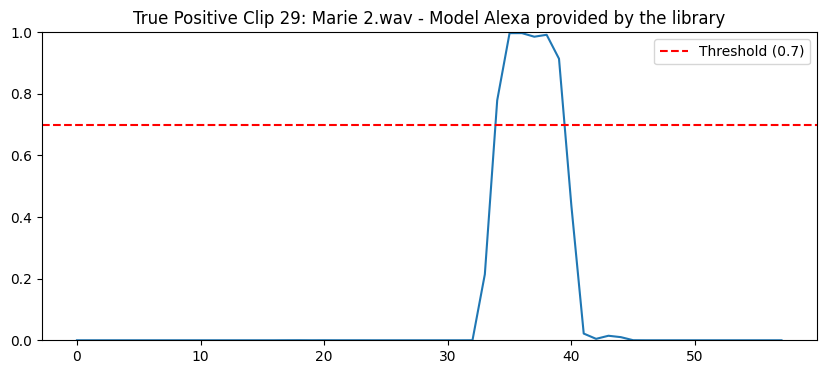

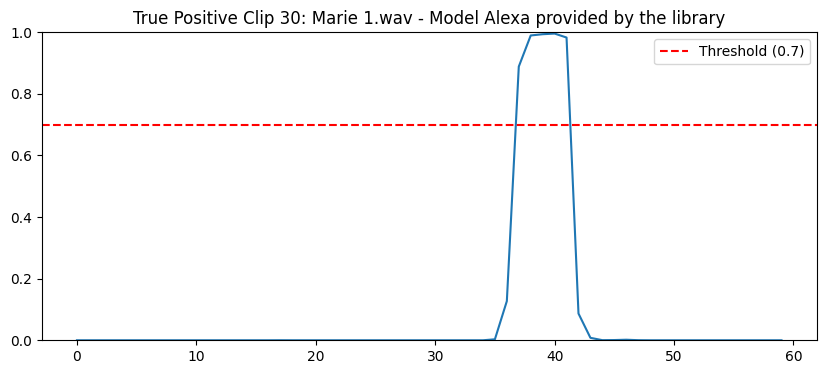

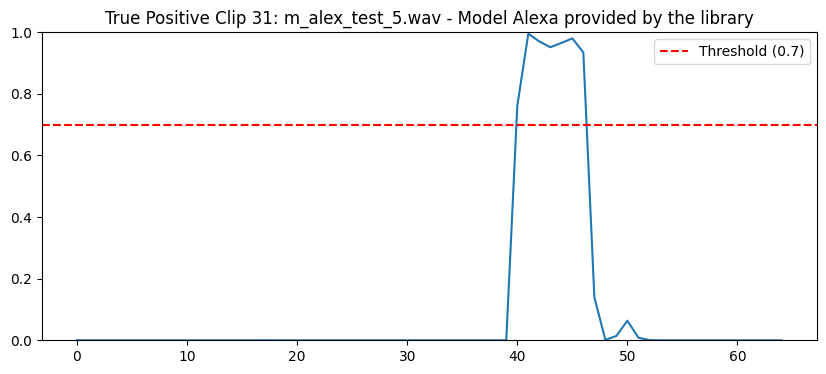

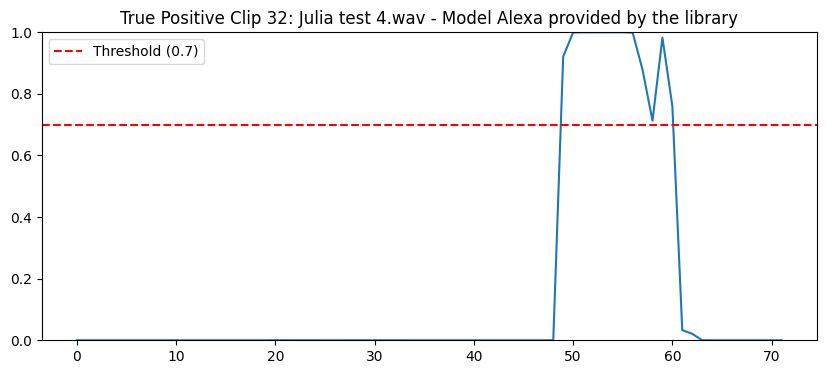

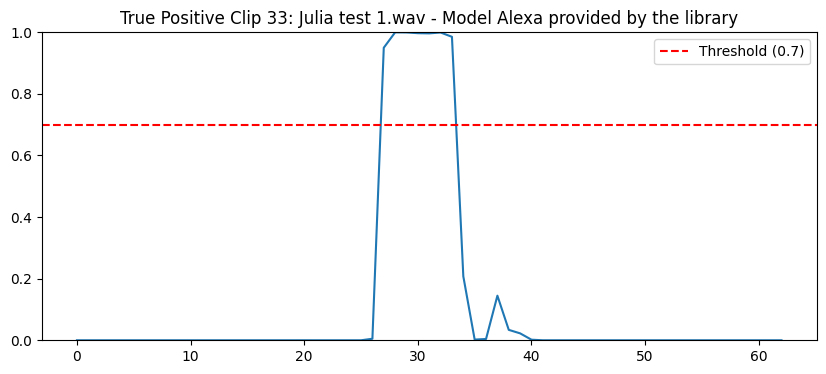

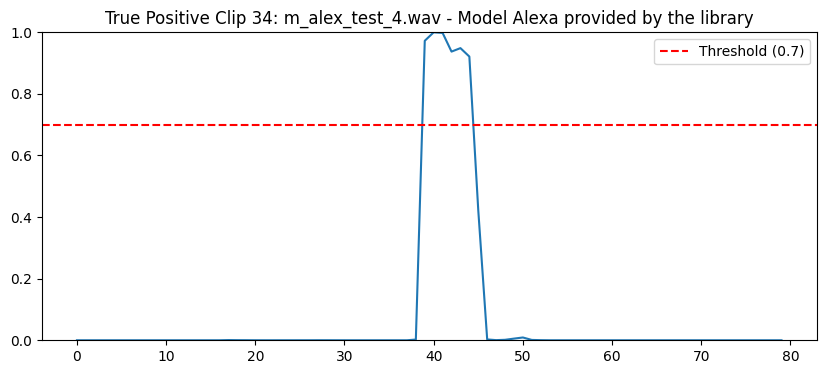

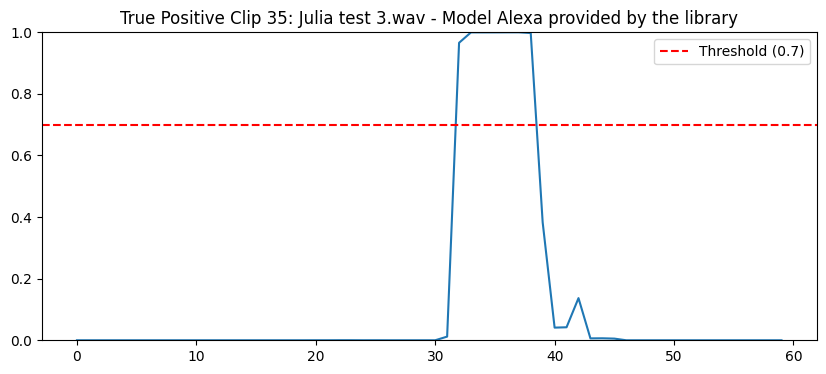

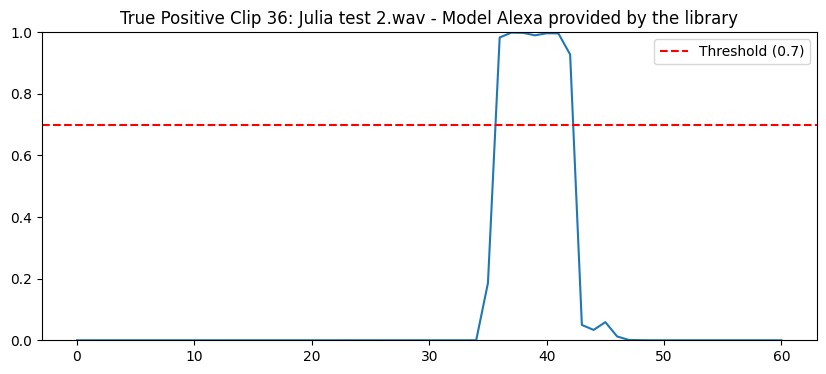

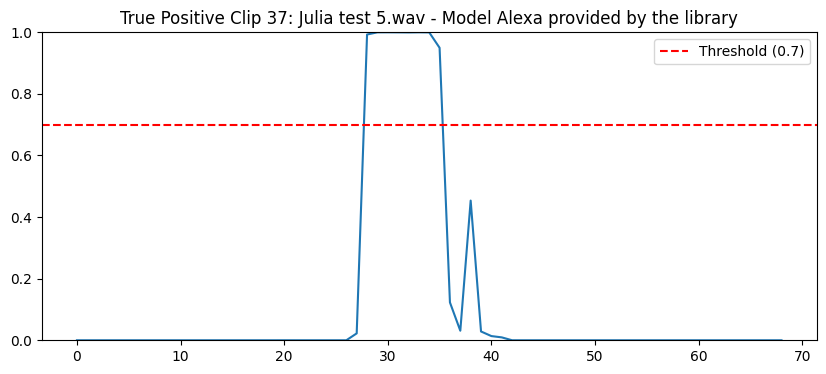

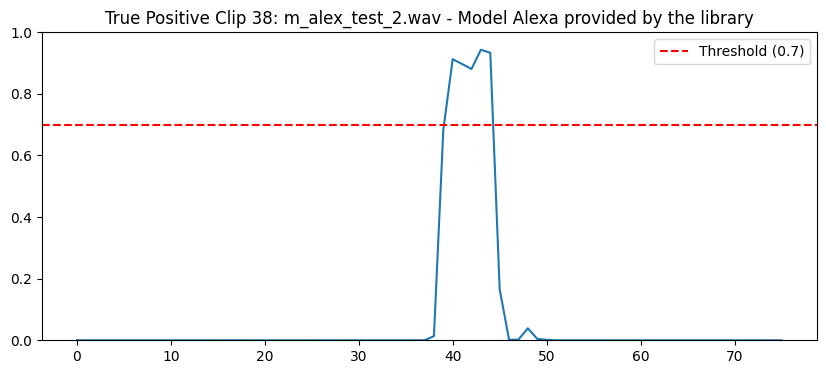

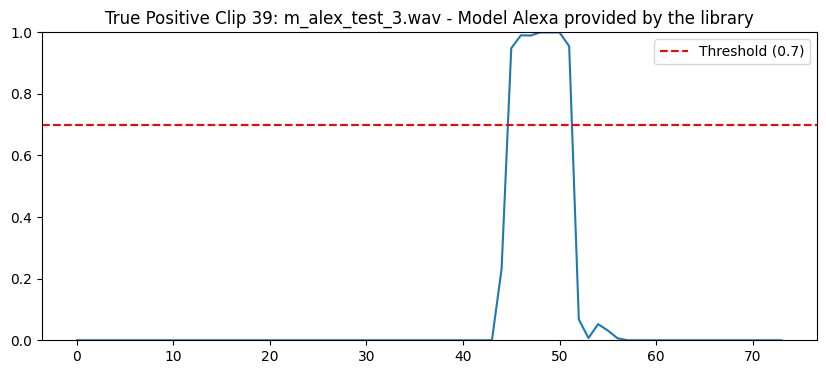

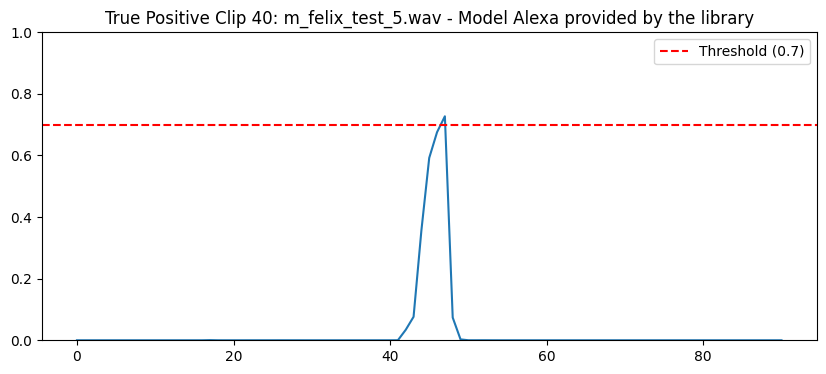

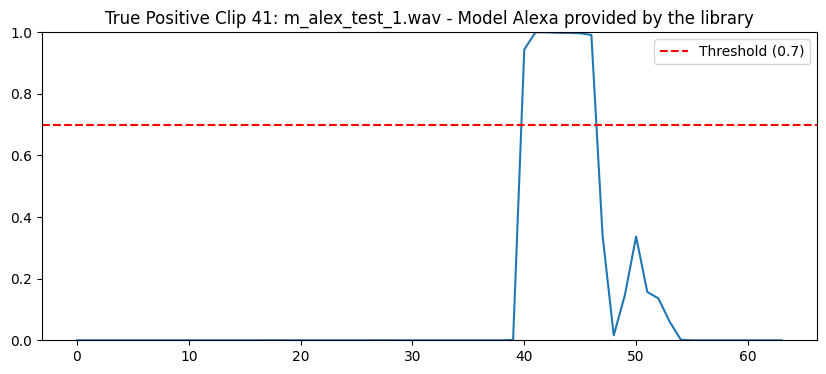

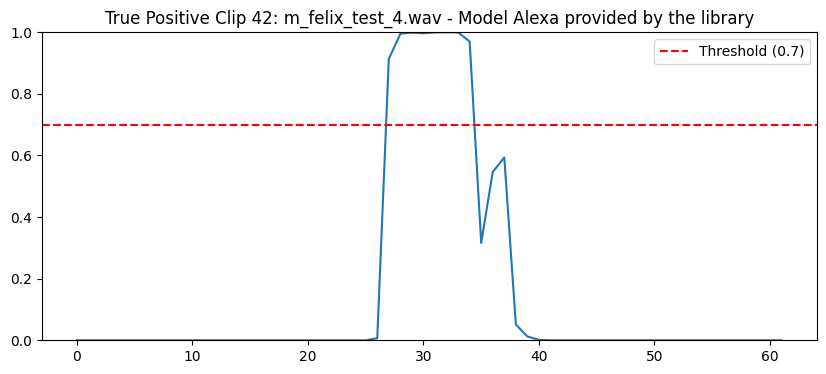

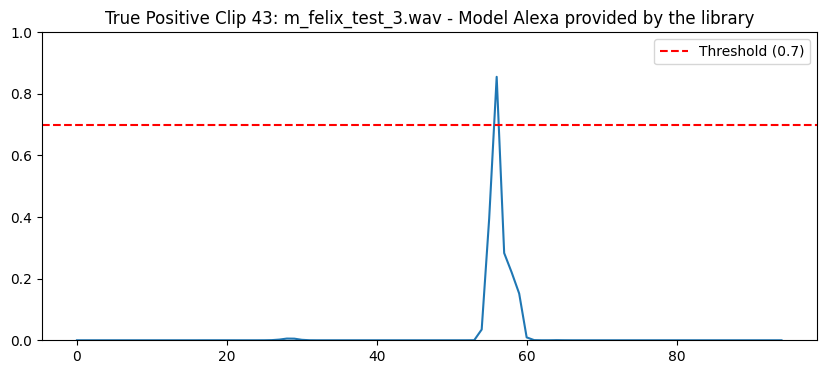

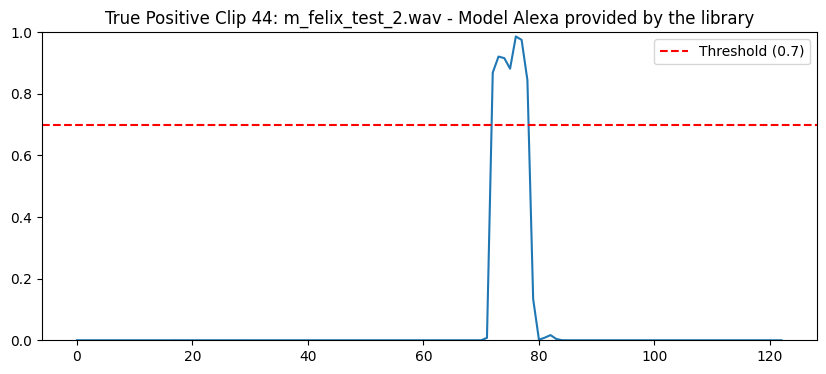

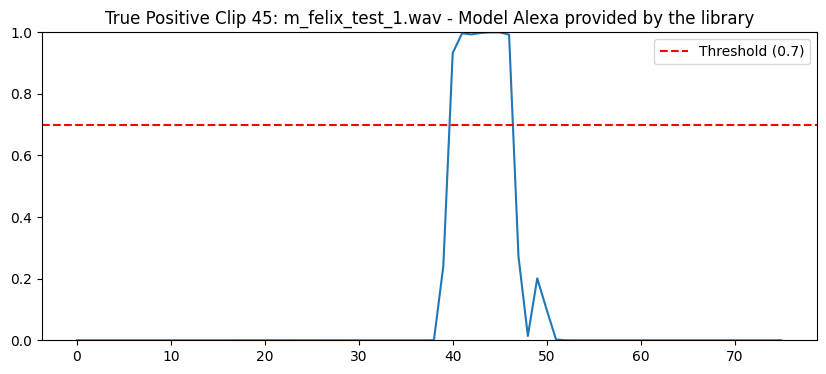


Results for model alexa':
True positive clips detected: 45 out of 45
Recall (True Acceptance Rate): 1.00


In [ ]:
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"


alexa_model = Model(wakeword_model_paths=[wakeword_alexa],)

true_positives_detected = 0
total_true_test_clips = len(false_test_clips)

print(f"Evaluating the alexa model")

for i, clip_path in enumerate(false_test_clips):
    scores_per_chunk = alexa_model.predict_clip(clip_path)
    alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

    # Check if there's any activation above the threshold in this clip
    if any(score > 0.7 for score in alexa_scores):
        true_positives_detected += 1

    # Optional: Plot for visual inspection (uncomment to see plots for each clip)
    plt.figure(figsize=(10, 4))
    plt.title(f"True Positive Clip {i+1}: {os.path.basename(clip_path)} - Model Alexa provided by the library")
    plt.plot(alexa_scores)
    plt.axhline(0.7, color='red', linestyle='--', label='Threshold (0.7)')
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    plt.close()

print(f"\nResults for model alexa':")
print(f"True positive clips detected: {true_positives_detected} out of {total_true_test_clips}")
if total_true_test_clips > 0:
    recall = true_positives_detected / total_true_test_clips
    print(f"Recall (True Acceptance Rate): {recall:.2f}")
else:
    print("No true test clips to evaluate.")

## Evaluation of the Custom Verifier

The goal of this evaluation is to investigate how the performance of the custom verifier changes when trained with different numbers of positive example audio clips containing the target speaker's voice and wake word.
The verifier is evaluated using different test scenarios to analyze its generalization capability. This includes a comparison of performance on male and female speaker data, an evaluation on the Santa Barbara Corpus test data.
The final goal is to determine whether the verifier provides sufficient reliability to be considered as a potential security feature for future software applications.




### Train the verifier

In [ ]:
SAMPLE_SIZES = [3, 6, 10]
summary_results = {}
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

sb_audio, sb_sr = sf.read(sb_corpus_clip)

for n_pos in SAMPLE_SIZES:

    # 1. Slice the first n_pos positive clips
    positive_train_clips = true_train_clips[:n_pos]
    model_path = f"/content/drive/MyDrive/speech_interaction/verifier/verifier_{n_pos}pos.pkl"


    # 2. Train a separate verifier for this version
    openwakeword.train_custom_verifier(
        positive_reference_clips=positive_train_clips,
        negative_reference_clips=false_train_clips,
        output_path=model_path,
        model_name='alexa'
    )

Processing negative reference clips: 100%|██████████| 11/11 [00:03<00:00,  3.17it/s]


Training and saving verifier model...
Done!


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Processing negative reference clips: 100%|██████████| 11/11 [00:03<00:00,  3.19it/s]


Training and saving verifier model...
Done!


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Processing negative reference clips: 100%|██████████| 11/11 [00:03<00:00,  3.13it/s]

Training and saving verifier model...
Done!


### Evaluation of the Verifier Using the Santa Barbara Corpus



In [ ]:
model_path = f"/content/drive/MyDrive/speech_interaction/verifier/"
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

sb_audio, sb_sr = sf.read(sb_corpus_clip)

print("Running false-positive analysis on the Santa Barbara corpus")

for filename in os.listdir(model_path):
  print(f"\nEvaluating verifier: {filename}")
  if not filename.endswith(".pkl"):
    continue

  verifier_model = Model(
      wakeword_model_paths=[wakeword_alexa],
      custom_verifier_models={'alexa': model_path + filename},
      custom_verifier_threshold=0.7
  )

  sb_scores_list = [i["alexa"] for i in verifier_model.predict_clip(sb_corpus_clip)]

  # Print some statistics about the scores
  print(f"  Max score: {np.max(sb_scores_list):.4f}")
  print(f"  Mean score: {np.mean(sb_scores_list):.4f}")
  print(f"  Number of scores above 0.7: {np.sum(np.array(sb_scores_list) > 0.7)}")

  plt.figure()
  plt.title(f"Alexa scores for: {filename}")
  plt.axhline(0.7, color="red", linestyle="--", linewidth=1, label="threshold (0.7)")
  plt.plot(sb_scores_list)
  _ = plt.ylim(0,1)
  plt.legend()
  plt.show()
  plt.close()


  # Calculate the false-accept rate per hour from this new result

  false_accepts = openwakeword.metrics.get_false_positives(
      sb_scores_list, threshold=0.7
  )

  print(f"  False-accept rate per hour: {false_accepts/1:.2f}")

Running false-positive analysis on the Santa Barbara corpus

Evaluating verifier: verifier_3pos.pkl


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


KeyboardInterrupt: 

### Evaluation of True Positive Samples Using the Custom Verifier

In [ ]:
model_path = f"/content/drive/MyDrive/speech_interaction/verifier/"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

print("Evaluating verifiers on true positive test clips...")

verifier_results = {}
total_true_test_clips = len(true_test_clips)

for filename in os.listdir(model_path):
  if not filename.endswith(".pkl"):
    continue

  verifier_name = filename.replace(".pkl", "")
  print(f"\nEvaluating verifier: {verifier_name}")

  verifier_model = Model(
      wakeword_model_paths=[wakeword_alexa],
      custom_verifier_models={'alexa': os.path.join(model_path, filename)},
      custom_verifier_threshold=0.8
  )

  true_positives_detected = 0
  for clip_path in true_test_clips:
    scores_per_chunk = verifier_model.predict_clip(clip_path)
    alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

    # Check if there's any activation above the threshold in this clip
    if any(score > verifier_model.custom_verifier_threshold for score in alexa_scores):
        true_positives_detected += 1

  verifier_results[verifier_name] = {
      "true_positives": true_positives_detected,
      "total_clips": total_true_test_clips
  }

# Print summary table
print("\n--- Verifier Performance Summary (True Positive Test Clips) ---")
print(f"{"Verifier":<20} | {"True Positives":<15} | {"Total Clips":<12} | {"Recall (TPR)":<12}")
print("-" * 70)
for verifier_name, data in verifier_results.items():
    recall = data["true_positives"] / data["total_clips"] if data["total_clips"] > 0 else 0
    print(f"{verifier_name:<20} | {data['true_positives']:<15} | {data['total_clips']:<12} | {recall:<12.2f}")

Evaluating verifiers on true positive test clips...

Evaluating verifier: verifier_3pos

Evaluating verifier: verifier_10pos


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(



Evaluating verifier: verifier_6pos


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(



--- Verifier Performance Summary (True Positive Test Clips) ---
Verifier             | True Positives  | Total Clips  | Recall (TPR)
----------------------------------------------------------------------
verifier_3pos        | 0               | 5            | 0.00        
verifier_10pos       | 5               | 5            | 1.00        
verifier_6pos        | 5               | 5            | 1.00        


### Evaluate the verifier using the false test audios

test.  /content/drive/MyDrive/speech_interaction/verifier/verifier_6pos.pkl


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Evaluating verifier 'verifier_6pos.pkl' on 45 false positive test clips...


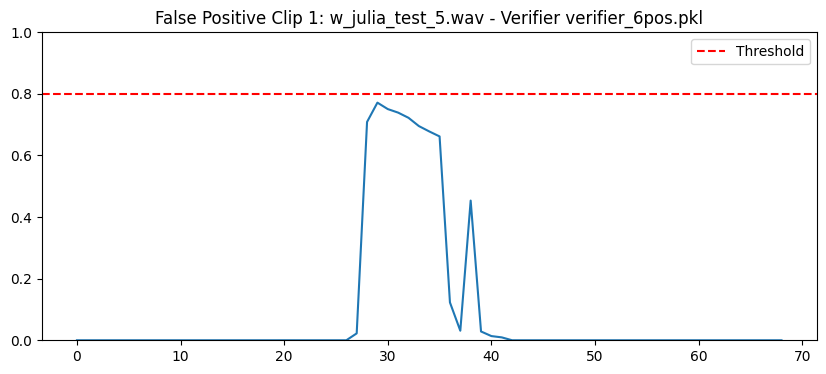

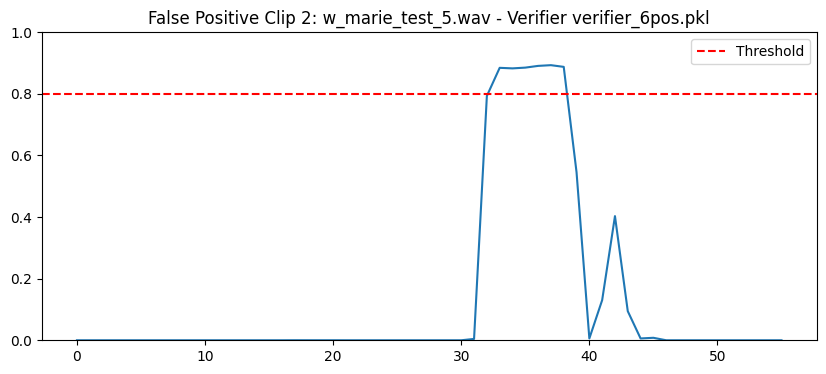

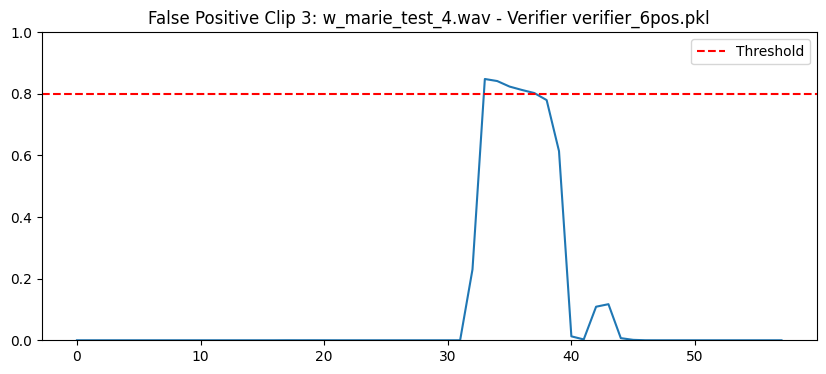

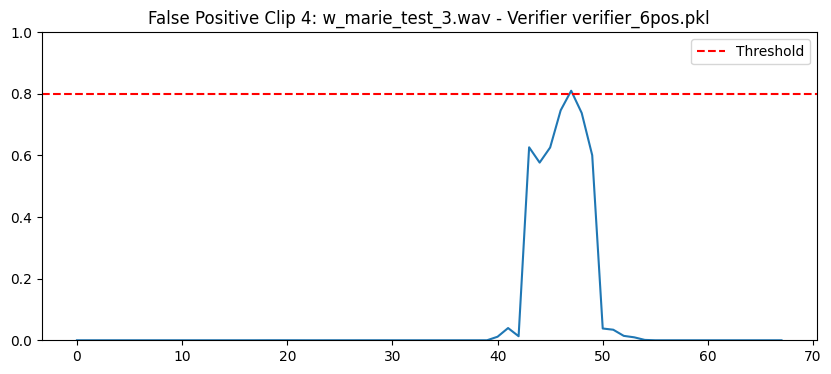

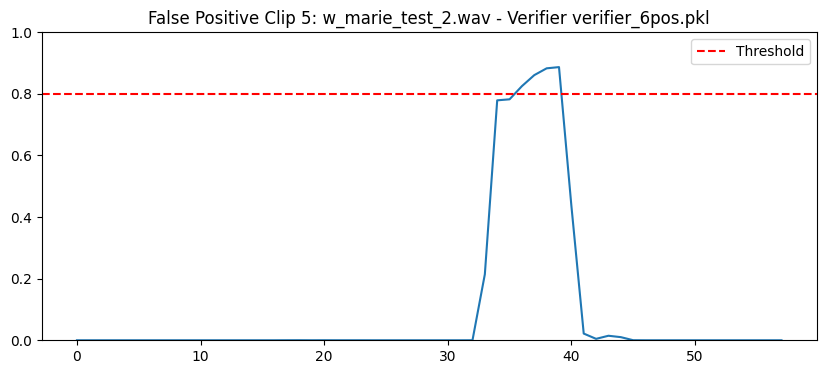

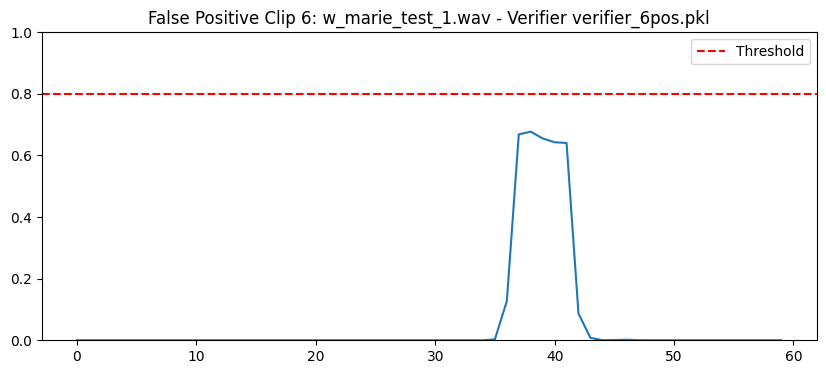

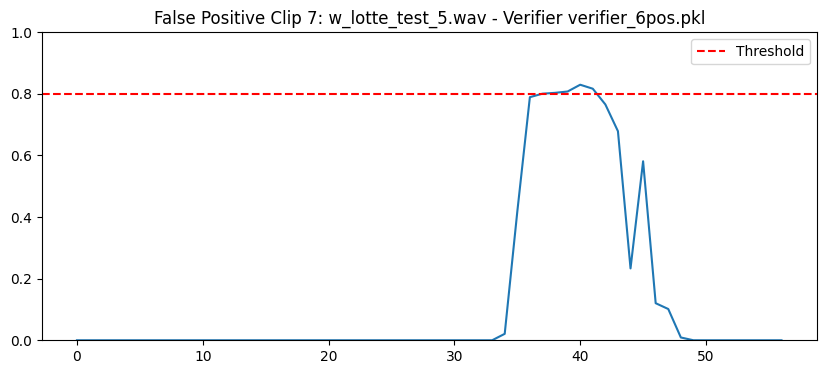

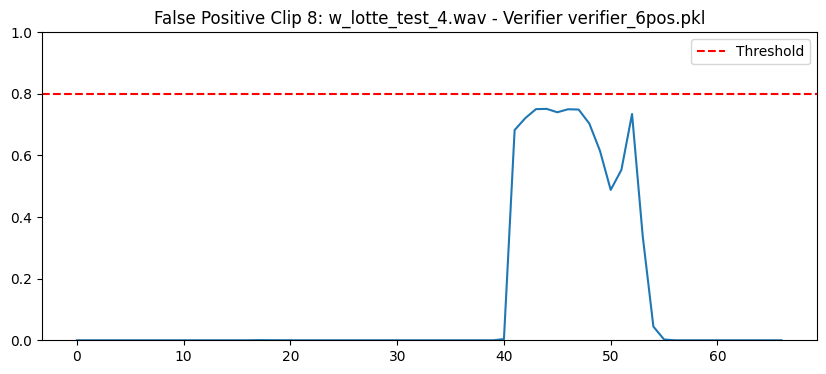

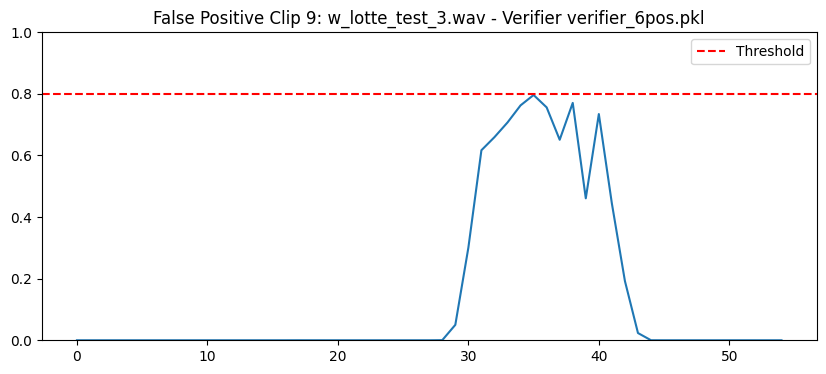

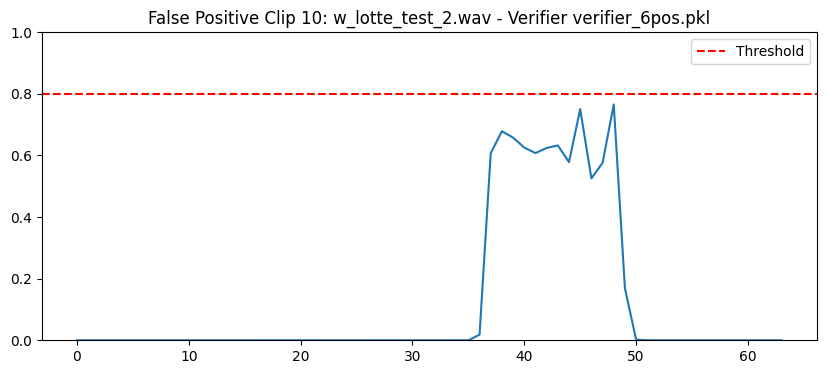

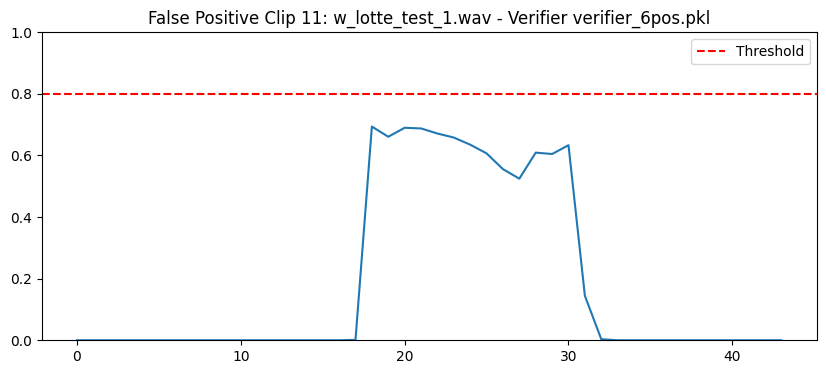

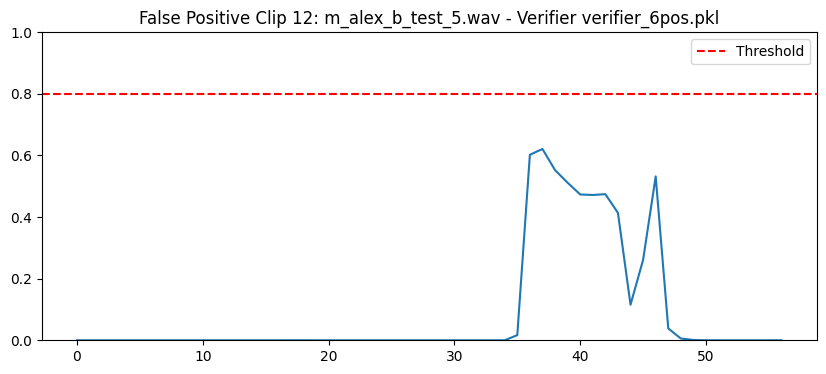

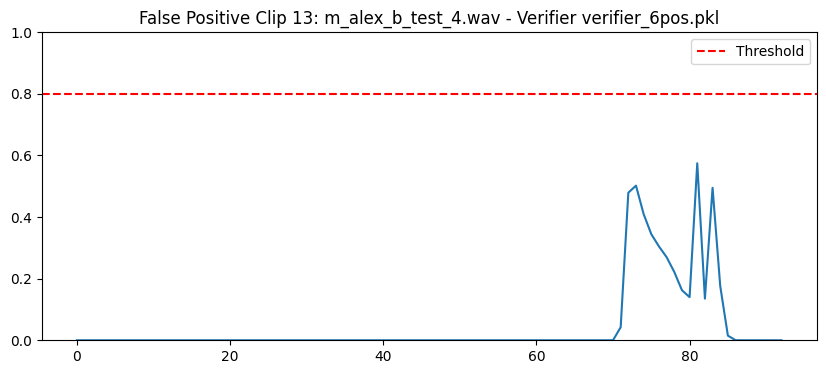

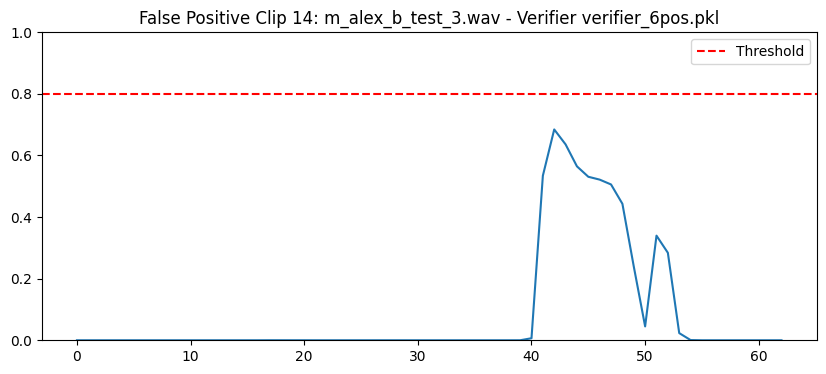

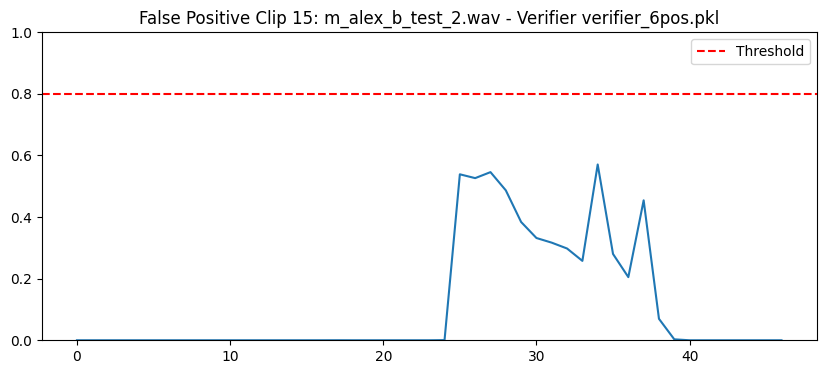

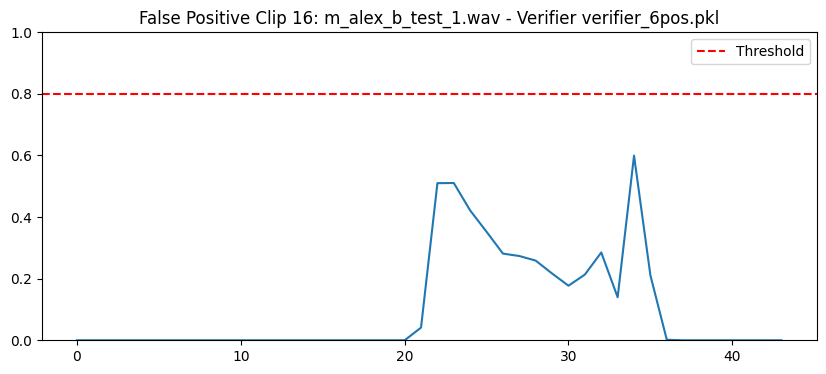

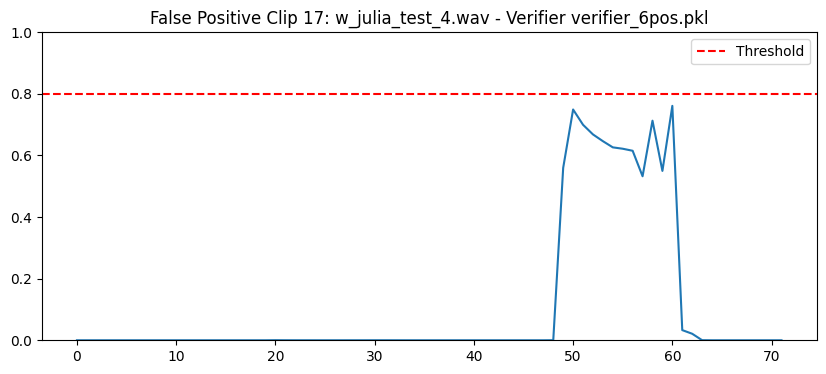

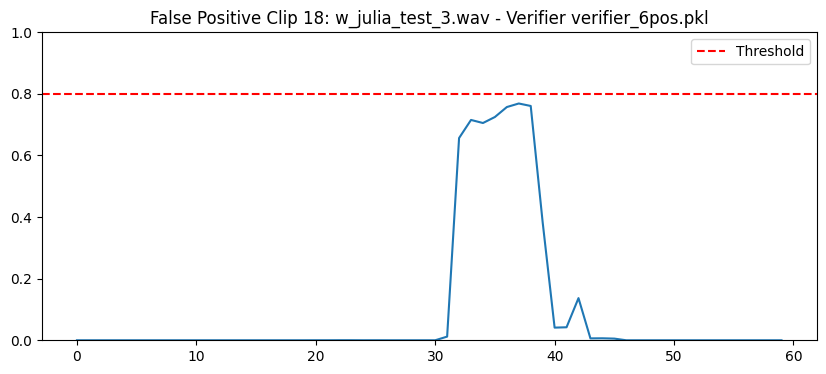

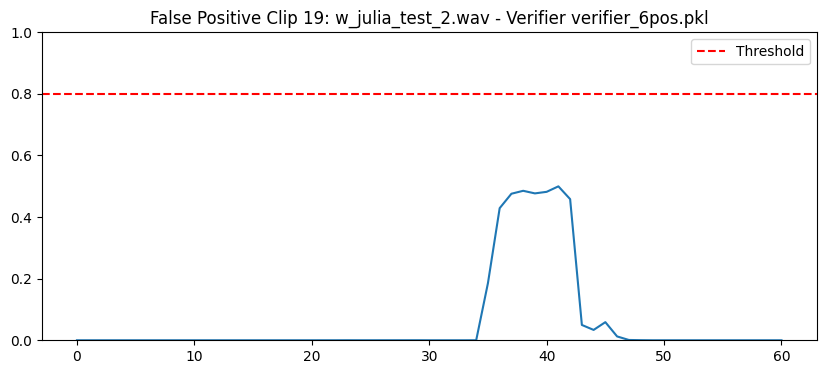

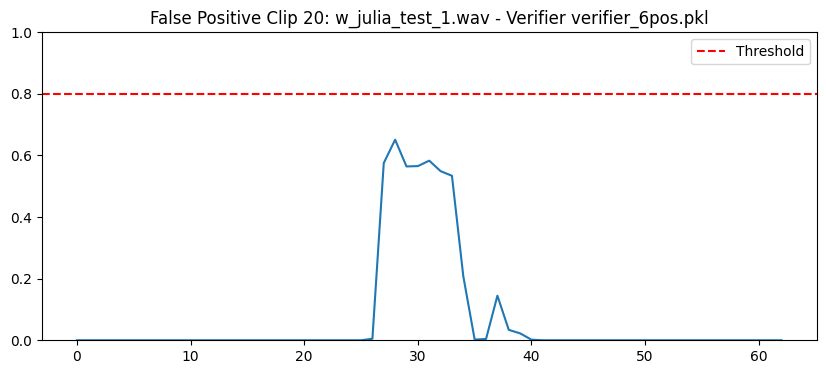

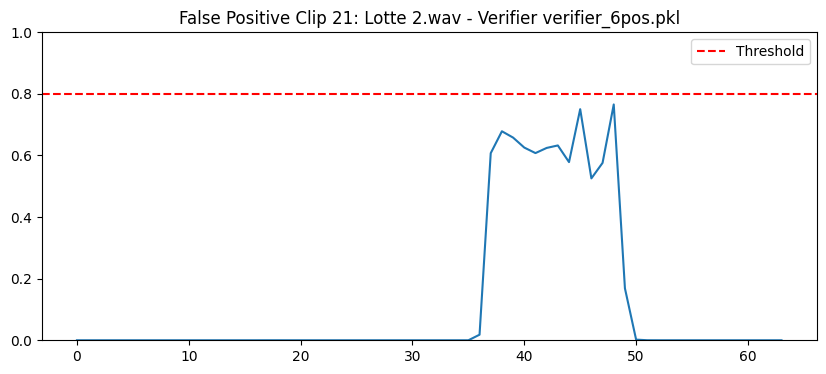

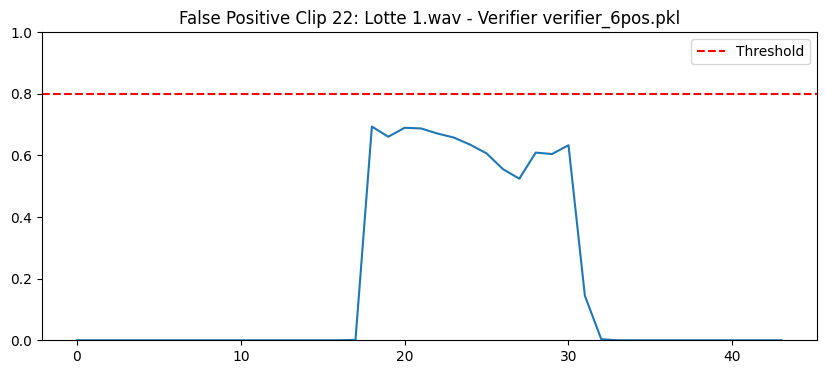

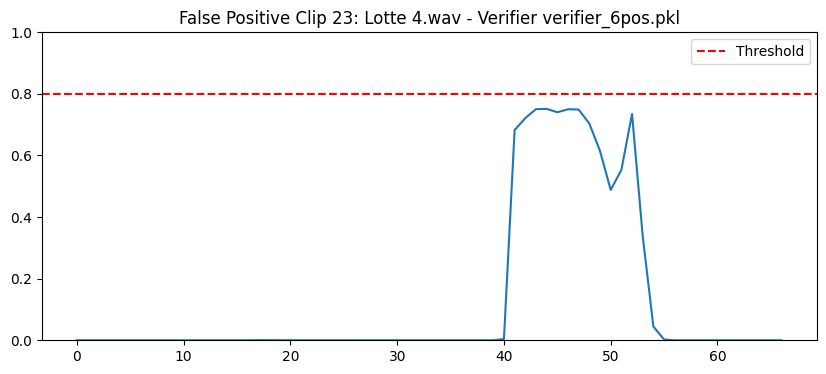

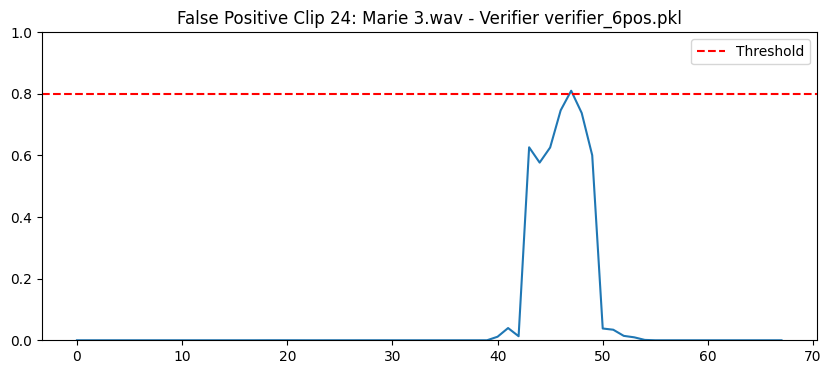

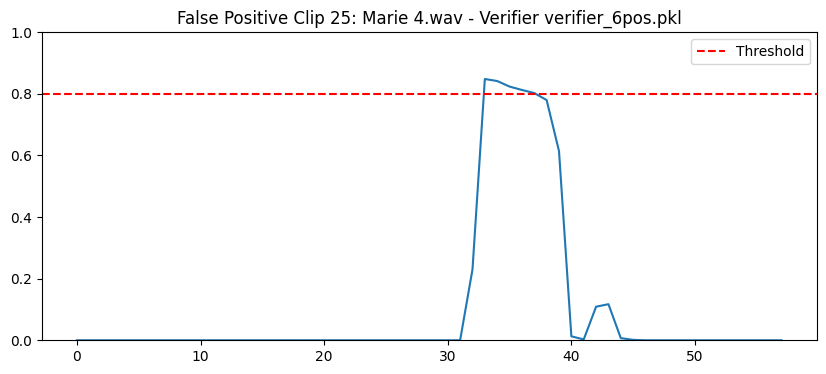

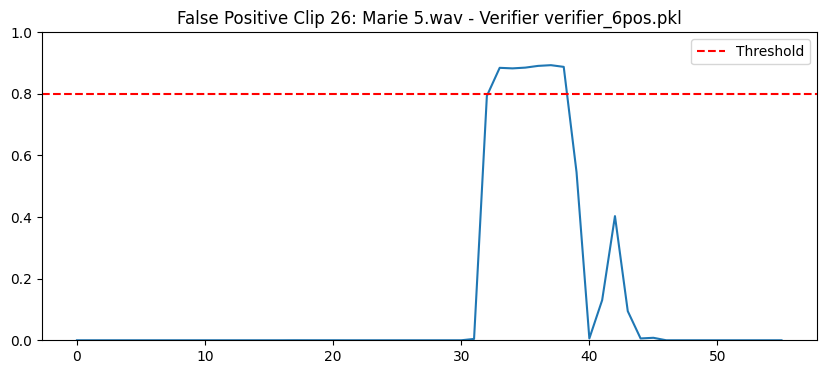

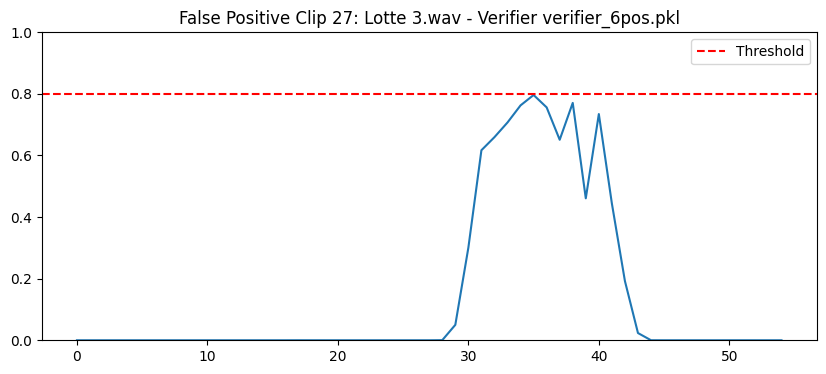

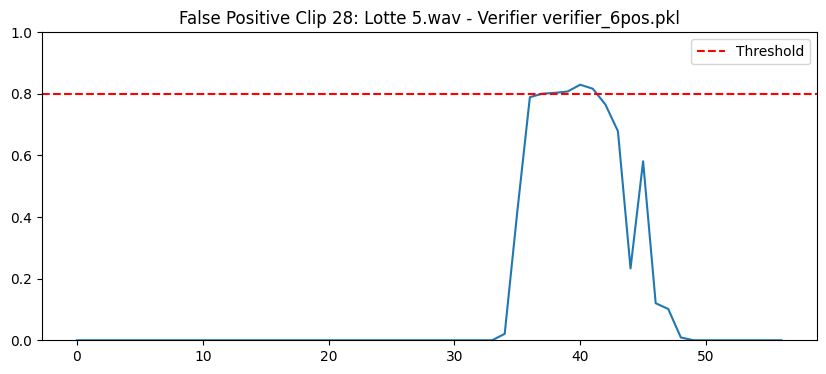

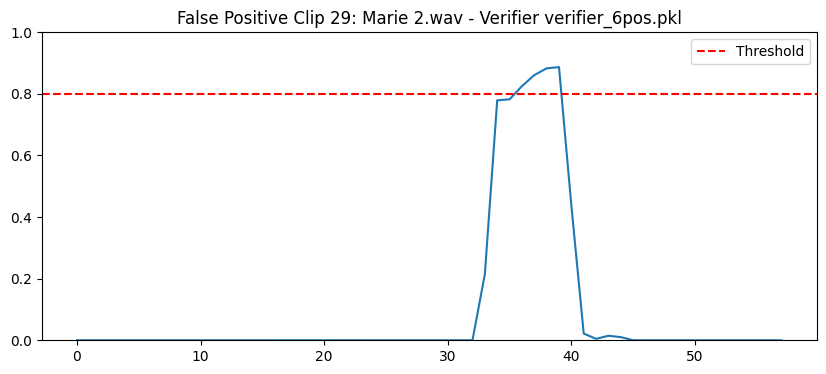

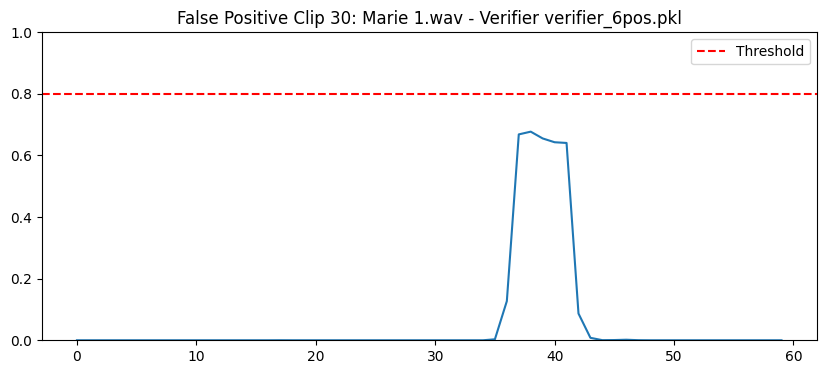

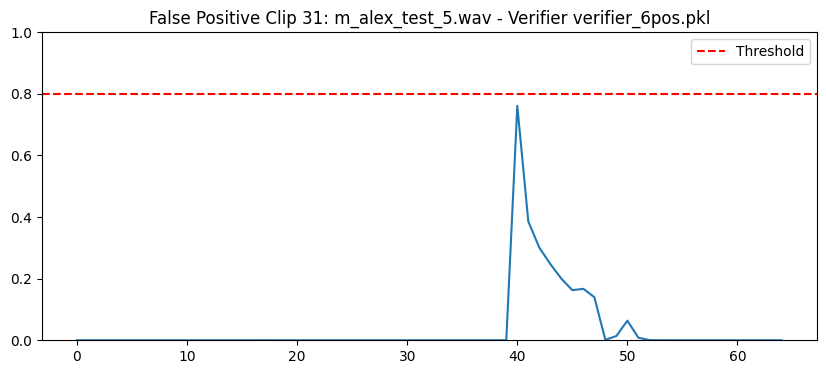

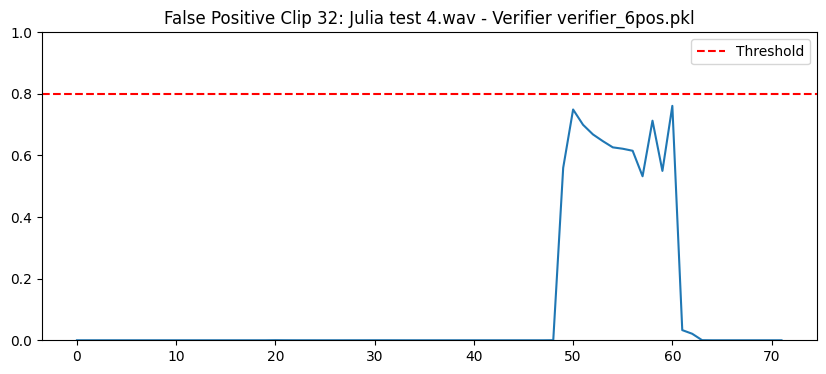

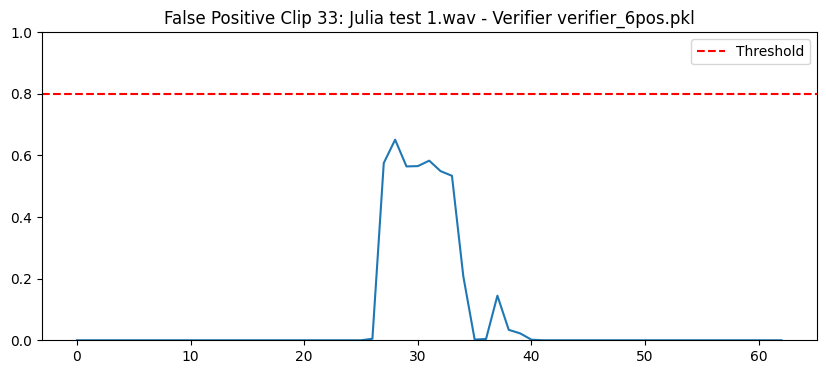

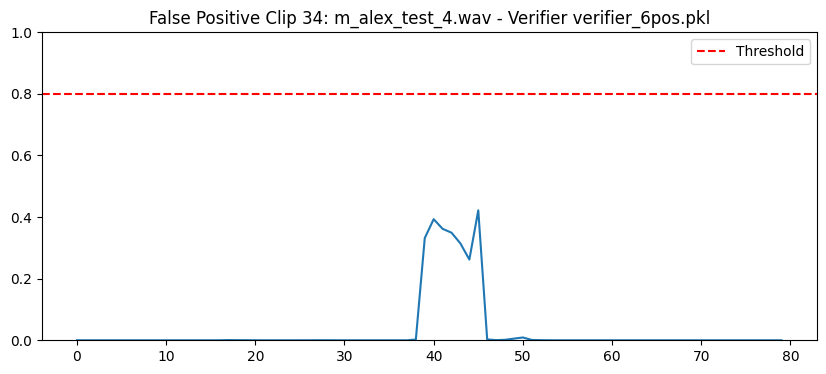

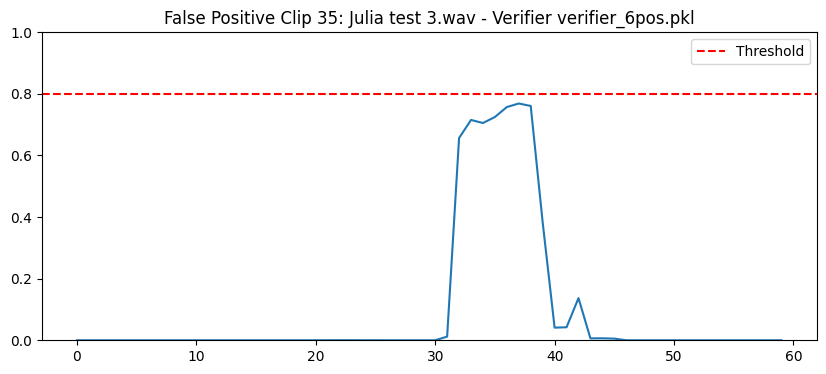

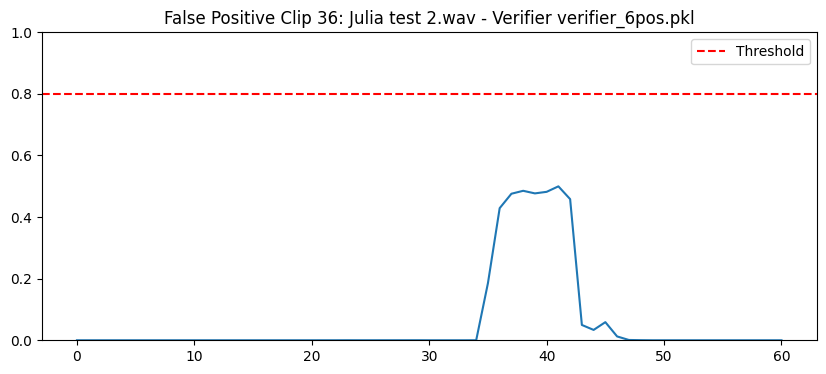

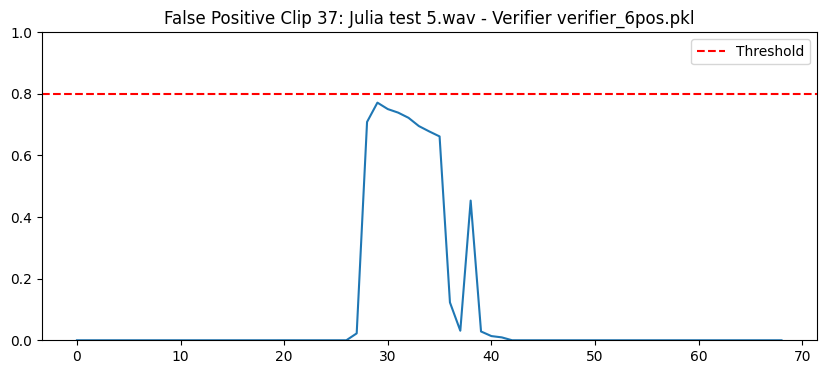

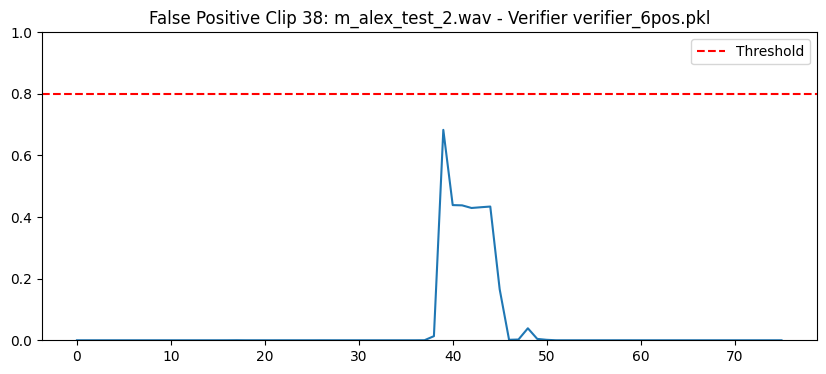

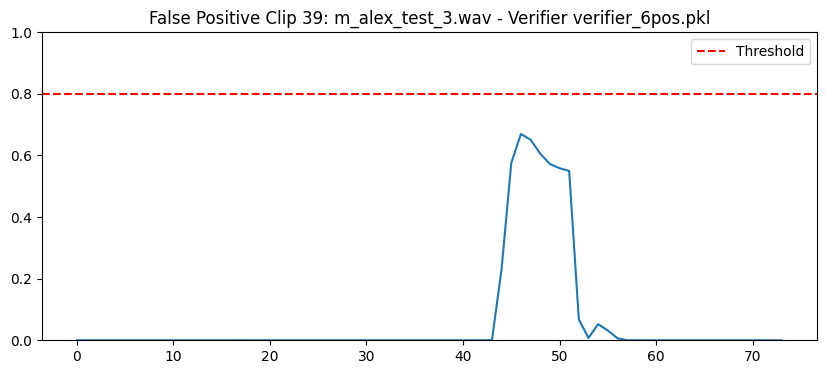

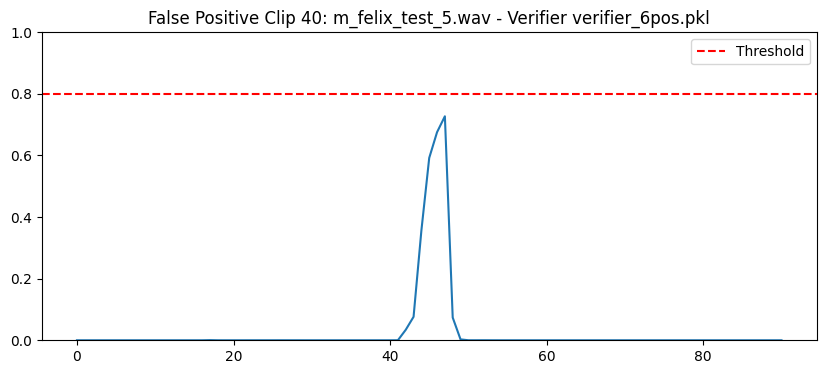

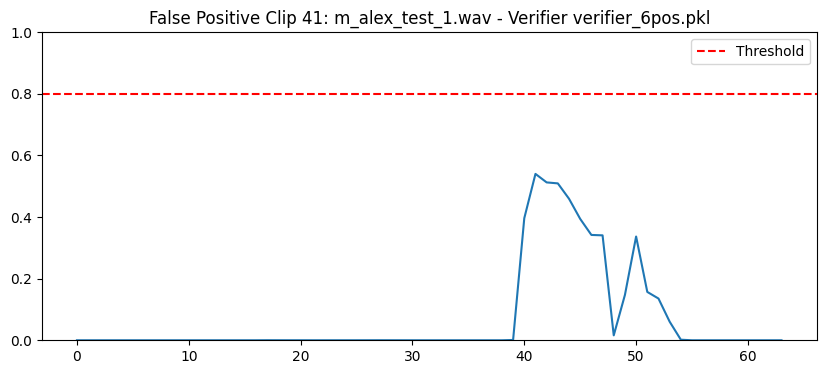

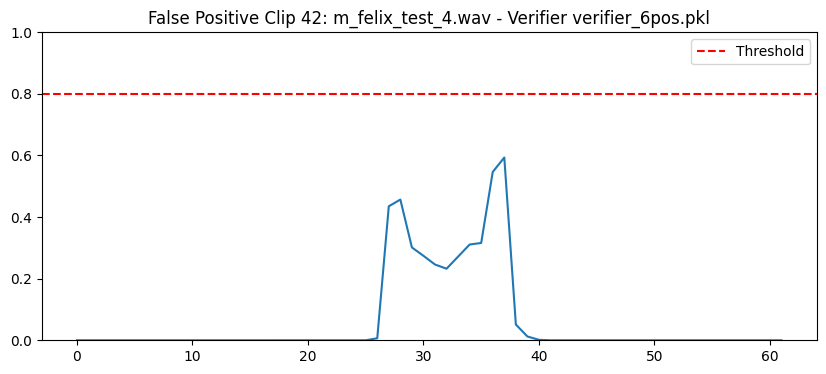

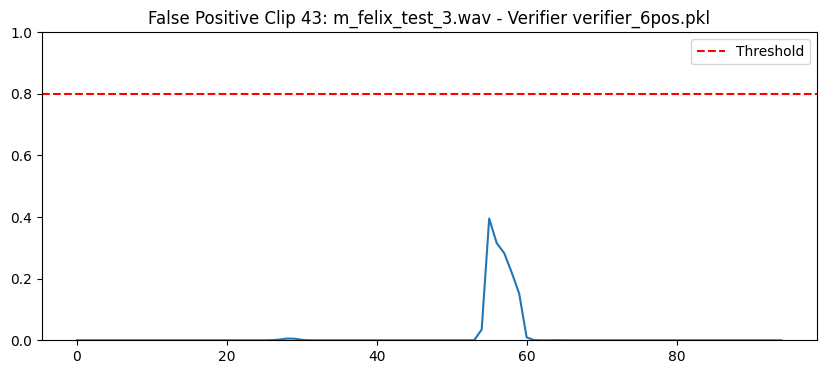

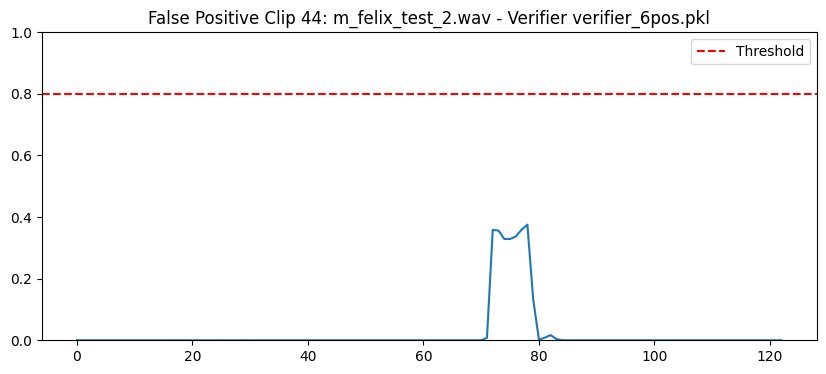

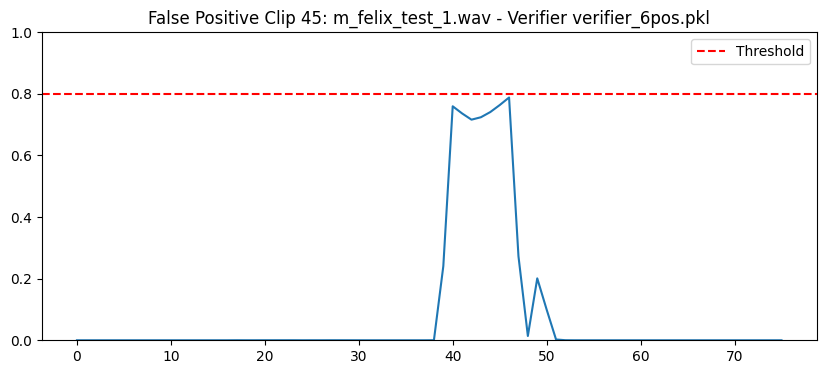


Results for verifier 'verifier_6pos.pkl':
False positive clips detected: 10 out of 45
False Acceptance Rate (FAR): 0.22


In [ ]:
chosen_verifier_filename = "verifier_6pos.pkl"
model_path = f"/content/drive/MyDrive/speech_interaction/verifier/"

verifier_to_evaluate_path = os.path.join(model_path, chosen_verifier_filename)

# Load the specific verifier model
verifier_model_true_test = Model(
    wakeword_model_paths=[wakeword_alexa],
    custom_verifier_models={'alexa': verifier_to_evaluate_path},
    custom_verifier_threshold=0.8
)

false_positives_detected = 0
total_false_test_clips = len(false_test_clips)

print(f"Evaluating verifier '{chosen_verifier_filename}' on {total_false_test_clips} false positive test clips...")

for i, clip_path in enumerate(false_test_clips):
    scores_per_chunk = verifier_model_true_test.predict_clip(clip_path)
    alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

    # Check if there's any activation above the threshold in this clip
    if any(score > verifier_model_true_test.custom_verifier_threshold for score in alexa_scores):
        false_positives_detected += 1

    # Optional: Plot for visual inspection (uncomment to see plots for each clip)
    plt.figure(figsize=(10, 4))
    plt.title(f"False Positive Clip {i+1}: {os.path.basename(clip_path)} - Verifier {chosen_verifier_filename}")
    plt.plot(alexa_scores)
    plt.axhline(verifier_model_true_test.custom_verifier_threshold, color='red', linestyle='--', label='Threshold')
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    plt.close()

print(f"\nResults for verifier '{chosen_verifier_filename}':")
print(f"False positive clips detected: {false_positives_detected} out of {total_false_test_clips}")
if total_false_test_clips > 0:
    false_acceptance_rate = false_positives_detected / total_false_test_clips
    print(f"False Acceptance Rate (FAR): {false_acceptance_rate:.2f}")
else:
    print("No false test clips to evaluate.")

Since the verifier trained with 6 positive audio clips achieved the best evaluation results, this model was selected for further analysis.


### Gender-Based Performance Evaluation

As we now have the custom verifier we want to test whether the trained Custom Verifier exhibits different false acceptance behavior for male and female voices.

#### Dividing Test Dataset


In [ ]:
male_test_clips = []
female_test_clips = []

for clip in false_test_clips:
  filename = os.path.basename(clip)

  if filename.startswith("m"):
    male_test_clips.append(clip)
  elif filename.startswith("w"):
    female_test_clips.append(clip)

print(f"Number of male test clips: {len(male_test_clips)}")
print(f"Number of female test clips: {len(female_test_clips)}")


Number of male test clips: 15
Number of female test clips: 15


After training the custom verifier, different threshold values were evaluated to determine a suitable operating point. Based on the trade-off between false acceptance rate (FAR) and false rejection rate (FRR), a threshold of 0.8 was selected for further evaluation. Using this threshold, male and female test audio clips were evaluated separately to investigate whether the verifier performance differs depending on the speaker's gender.


#### Loading the Custom Verifier Model

In [ ]:
from openwakeword.custom_verifier_model import get_reference_clip_features
import pickle
from openwakeword.model import Model

verifier_path = "/content/drive/MyDrive/speech_interaction/verifier/verifier_6pos.pkl"

with open(verifier_path, "rb") as f:
    verifier = pickle.load(f)

wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

oww_model = Model(
    wakeword_model_paths=[wakeword_alexa]
)

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


#### Extracting the Verifier Score for an Audio Clip

This function extracts the required features from an audio clip and applies the custom verifier. The maximum probability score across all frames is used as the final verifier score for the complete audio clip.

In [ ]:
def get_verifier_clip_score(clip_path, verifier, oww_model):

    features = get_reference_clip_features(
        clip_path,
        oww_model,
        "alexa",
        threshold=0.0,
        N=5
    )

    probabilities = verifier.predict_proba(features)

    frame_scores = probabilities[:, 1]

    clip_score = frame_scores.max()

    return clip_score

#### False Acceptance Rate Evaluation

In [ ]:
def calculate_far(test_clips, verifier, oww_model, threshold=0.8):

    false_accepts = 0
    scores = []

    for clip in test_clips:

        score = get_verifier_clip_score(
            clip,
            verifier,
            oww_model
        )

        scores.append(score)

        if score >= threshold:
            false_accepts += 1

    far = false_accepts / len(test_clips)

    return far, false_accepts, scores

#### Evaluation on Male Speaker Audio Clips

In [ ]:
male_far, male_fa, male_scores = calculate_far(
    male_test_clips,
    verifier,
    oww_model,
    threshold=0.8
)

print("Male FAR:", male_far)
print("Male false accepts:", male_fa)

Male FAR: 0.0
Male false accepts: 0


#### Evaluation on Female Speaker Audio Clips

In [ ]:
female_far, female_fa, female_scores = calculate_far(
    female_test_clips,
    verifier,
    oww_model,
    threshold=0.8
)

print("Female FAR:", female_far)
print("Female false accepts:", female_fa)

Female FAR: 0.4
Female false accepts: 6


#### Comparison of False Acceptance Rate Between Male and Female Speakers

In [ ]:
speaker_groups = ["Male", "Female"]
far_values = [male_far, female_far]

plt.figure(figsize=(6,4))

bars = plt.bar(
    speaker_groups,
    far_values,
    color=["steelblue", "salmon"]
)

plt.ylabel("False Acceptance Rate (FAR)")
plt.xlabel("Gender")
plt.title("Comparison of FAR for Male and Female Speakers\n(Threshold = 0.8)")

plt.ylim(0, 1)

# Add percentage labels
for bar, value in zip(bars, far_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value*100:.1f}%",
        ha="center"
    )

plt.show()

The comparison of the false acceptance rates between male and female speakers shows a significant difference in verification performance. Using a threshold of 0.8, the custom verifier achieved a FAR of 0% for male speakers, meaning that none of the tested male speakers were incorrectly accepted as the target speaker.

In contrast, female speakers resulted in a considerably higher FAR of 40%. This indicates that the verifier was more likely to incorrectly classify female speakers as the target speaker. The results suggest that the trained verifier does not generalize equally across different speaker groups and may have learned characteristics that are more common among female voices.


#### Trying Different Thresholds

In [ ]:
thresholds = [0.7, 0.8, 0.85, 0.9, 0.95]

male_far_values = []
female_far_values = []

for t in thresholds:
    female_far, _, _ = calculate_far(
        female_test_clips,
        verifier,
        oww_model,
        threshold=t
    )

    male_far, _, _ = calculate_far(
        male_test_clips,
        verifier,
        oww_model,
        threshold=t
    )

    male_far_values.append(male_far)
    female_far_values.append(female_far)

    print(
        "Threshold:", t,
        "Male FAR:", male_far,
        "Female FAR:", female_far
    )

Threshold: 0.7 Male FAR: 0.13333333333333333 Female FAR: 0.9333333333333333
Threshold: 0.8 Male FAR: 0.0 Female FAR: 0.4
Threshold: 0.85 Male FAR: 0.0 Female FAR: 0.26666666666666666
Threshold: 0.9 Male FAR: 0.0 Female FAR: 0.13333333333333333
Threshold: 0.95 Male FAR: 0.0 Female FAR: 0.0


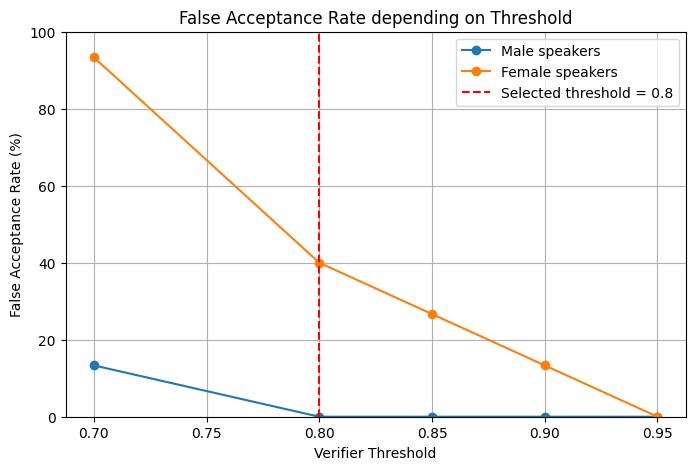

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    [x*100 for x in male_far_values],
    marker="o",
    label="Male speakers"
)

plt.plot(
    thresholds,
    [x*100 for x in female_far_values],
    marker="o",
    label="Female speakers"
)

plt.axvline(
    0.8,
    color="red",
    linestyle="--",
    label="Selected threshold = 0.8"
)

plt.xlabel("Verifier Threshold")
plt.ylabel("False Acceptance Rate (%)")
plt.title("False Acceptance Rate depending on Threshold")

plt.ylim(0,100)
plt.grid(True)
plt.legend()

plt.show()

The threshold evaluation shows a clear trade-off between false acceptance rate (FAR) and false rejection rate (FRR). At a low threshold of 0.7, the verifier is very permissive: all target speaker samples are accepted (FRR = 0%), but the false acceptance rate is very high, especially for female speakers (93.3%). Increasing the threshold improves the rejection of non-target speakers.

A threshold of 0.8 provides the best balance for the evaluated dataset. It achieves a false rejection rate of 0% while reducing false accepts significantly compared to 0.7 (0% FAR for male speakers and 40% FAR for female speakers). Increasing the threshold further to 0.85 slightly improves the rejection of female speakers, but already introduces false rejections of the target speaker (FRR = 20%).

At a threshold of 0.9, the false acceptance rate reaches 0% for both male and female speakers, but this comes at the cost of a high false rejection rate of 60%. A threshold of 0.95 completely rejects all target speaker samples (FRR = 100%), making it unsuitable for practical use.

Overall, the results indicate that a threshold around 0.8 offers the best compromise between security and usability for this verifier configuration. Higher thresholds improve security against false accepts but significantly reduce the reliability of recognizing the target speaker.
